In [8]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2"
import clip
import torch
import torch.nn as nn
import numpy as np
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
from pycocotools.coco import COCO
from PIL import Image

print("using {} device.".format(device))
clip_model, img_preprocess = clip.load("RN50", device = device)
clip_model = clip_model.float()
    
class CombinedModel(nn.Module):
    def __init__(self, clip_model):
        super(CombinedModel, self).__init__()
        self.clip_model = clip_model
        self.visual_projector = nn.Sequential(
            nn.Linear(1024, 1024),
            nn.LayerNorm(1024),
            nn.ReLU()
        )
        self.text_projector = nn.Sequential(
            nn.Linear(1024, 1024),
            nn.LayerNorm(1024),
            nn.ReLU()
        )

    def forward(self, img_input, text_input):
        img_feats = self.clip_model.encode_image(img_input)
        img_feats = self.visual_projector(img_feats)
        text_feats = self.clip_model.encode_text(text_input)
        text_feats = self.text_projector(text_feats)
        return img_feats, text_feats

# 组合CLIP和自定义网络
combined_model = CombinedModel(clip_model).to(device)
param_dict = torch.load("/home/bd/data/zs/FedMMDP/saved/projector_weights/norm.pth")
combined_model.visual_projector.load_state_dict(param_dict['visual_projector'].state_dict())
combined_model.text_projector.load_state_dict(param_dict['text_projector'].state_dict())
combined_model.eval()

cuda
using cuda device.


CombinedModel(
  (clip_model): CLIP(
    (visual): ModifiedResNet(
      (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu1): ReLU(inplace=True)
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu2): ReLU(inplace=True)
      (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu3): ReLU(inplace=True)
      (avgpool): AvgPool2d(kernel_size=2, stride=2, padding=0)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_

In [2]:
np.random.seed(0)
train_instances_info = "/home/bd/data/zs/data/COCO/annotations/instances_train2017.json"
train_captions_info = "/home/bd/data/zs/data/COCO/annotations/captions_train2017.json"
train_image = "/home/bd/data/zs/data/COCO/train2017"

# 加载COCO数据集
coco_captions = COCO(train_captions_info)
train_ids = list(coco_captions.imgs)
random_index=np.random.choice(range(len(train_ids)), size=5000, replace=False)
subset_ids=np.array(train_ids)[random_index]

loading annotations into memory...
Done (t=0.75s)
creating index...
index created!


In [3]:
# 预处理图像
images = []
for i in range(len(subset_ids)):
    img_info = coco_captions.loadImgs(subset_ids)[i]
    img_path = os.path.join('/home/bd/data/zs/data/COCO', 'train2017', img_info['file_name'])
    image = img_preprocess(Image.open(img_path)).unsqueeze(0).to(device)
    images.append(image)
    
captions = [coco_captions.loadAnns(coco_captions.getAnnIds(img_id))[0]['caption'] for img_id in subset_ids]

with torch.no_grad():
    # 初始化用于存储特征的列表
    image_features_list = []
    text_features_list = []
    
    # 批量处理以提高效率
    batch_size = 32
    for i in range(0, len(images), batch_size):
        end = min(i + batch_size, len(images))
        
        # 准备当前批次的图像数据
        batch_imgs = torch.cat(images[i:end])
        
        # 准备当前批次的文本数据
        batch_text = clip.tokenize(captions[i:end]).to(device)
        
        # 使用combined_model处理图像和文本
        img_feats, txt_feats = combined_model(batch_imgs, batch_text)
        
        # 归一化特征
        img_feats = img_feats / img_feats.norm(dim=-1, keepdim=True)
        txt_feats = txt_feats / txt_feats.norm(dim=-1, keepdim=True)
        
        # 保存特征
        image_features_list.append(img_feats.cpu().numpy())
        text_features_list.append(txt_feats.cpu().numpy())
    
    # 合并所有批次的特征
    image_features = np.concatenate(image_features_list, axis=0)
    text_features = np.concatenate(text_features_list, axis=0)

# np.save('./img_emb_0.npy', image_features)
# np.save('./txt_emb_0.npy', text_features)

/tmp/ipykernel_1430112/1270349706.py:27: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(image_tsne[:, 0], image_tsne[:, 1], c=sns.color_palette("hls")[0], label='Image Features', alpha=0.5, s=10)
/tmp/ipykernel_1430112/1270349706.py:30: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(text_tsne[:, 0], text_tsne[:, 1],c=sns.color_palette("hls")[1], label='Text Features', alpha=0.5, s=10)


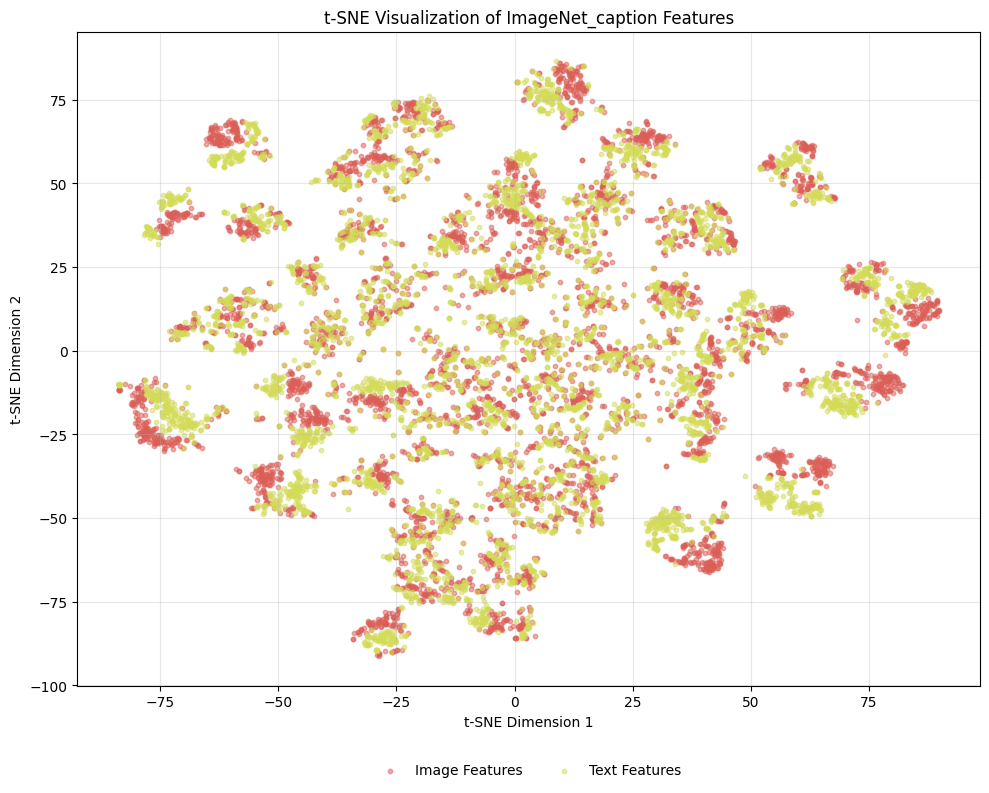

In [5]:
# 假设image_features和text_features是已经加载好的特征数据
# image_features和text_features的形状应该是 (num_samples, feature_dim)

# image_features = np.load('./img_emb_0.npy')
# text_features = np.load('./txt_emb_0.npy')
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.manifold import TSNE

sns.color_palette("hls")

# 将image_features和text_features合并为一个数组
combined_feats = np.concatenate((image_features, text_features), axis=0)
# combined_feats = np.concatenate((tmp_img_embeds.cpu(), tmp_txt_embeds.cpu()), axis=0)

# 创建t-SNE模型并拟合数据
tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(combined_feats)

# 分离image_features和text_features的t-SNE结果
image_tsne = tsne_results[:image_features.shape[0]]
text_tsne = tsne_results[image_features.shape[0]:]

plt.figure(figsize=(10, 8))  # 调整图表尺寸以符合论文规范

# 绘制图像特征点
plt.scatter(image_tsne[:, 0], image_tsne[:, 1], c=sns.color_palette("hls")[0], label='Image Features', alpha=0.5, s=10)

# 绘制文本特征点
plt.scatter(text_tsne[:, 0], text_tsne[:, 1],c=sns.color_palette("hls")[1], label='Text Features', alpha=0.5, s=10)

# 添加标题和标签
plt.title('t-SNE Visualization of ImageNet_caption Features', fontsize=12)
plt.xlabel('t-SNE Dimension 1', fontsize=10)
plt.ylabel('t-SNE Dimension 2', fontsize=10)

# 添加网格
plt.grid(alpha=0.3)

# 优化图例显示
plt.legend(fontsize=10, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2, frameon=False)

# 调整布局
plt.tight_layout()

# 保存为高分辨率 PDF
plt.savefig('tsne_visualization.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.savefig('tsne_visualization.png', format='png', dpi=300, bbox_inches='tight')

# 显示图表
plt.show()

Running FINCH clustering...
Partition 0: 1945 clusters
Partition 1: 433 clusters
Partition 2: 110 clusters
Partition 3: 40 clusters
Partition 4: 21 clusters
Partition 5: 19 clusters
Partition 6: 18 clusters
[[   0    0    0 ...    0    0    0]
 [   1    1    1 ...    1    1    1]
 [   2    2    2 ...    2    2    2]
 ...
 [1839  430   15 ...   10   10   10]
 [ 851  330   12 ...    7    7    7]
 [1496  364   34 ...   17   16   15]]
FINCH found 110 clusters at partition level 2
Performing t-SNE dimensionality reduction...


/tmp/ipykernel_1299384/3404303908.py:68: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


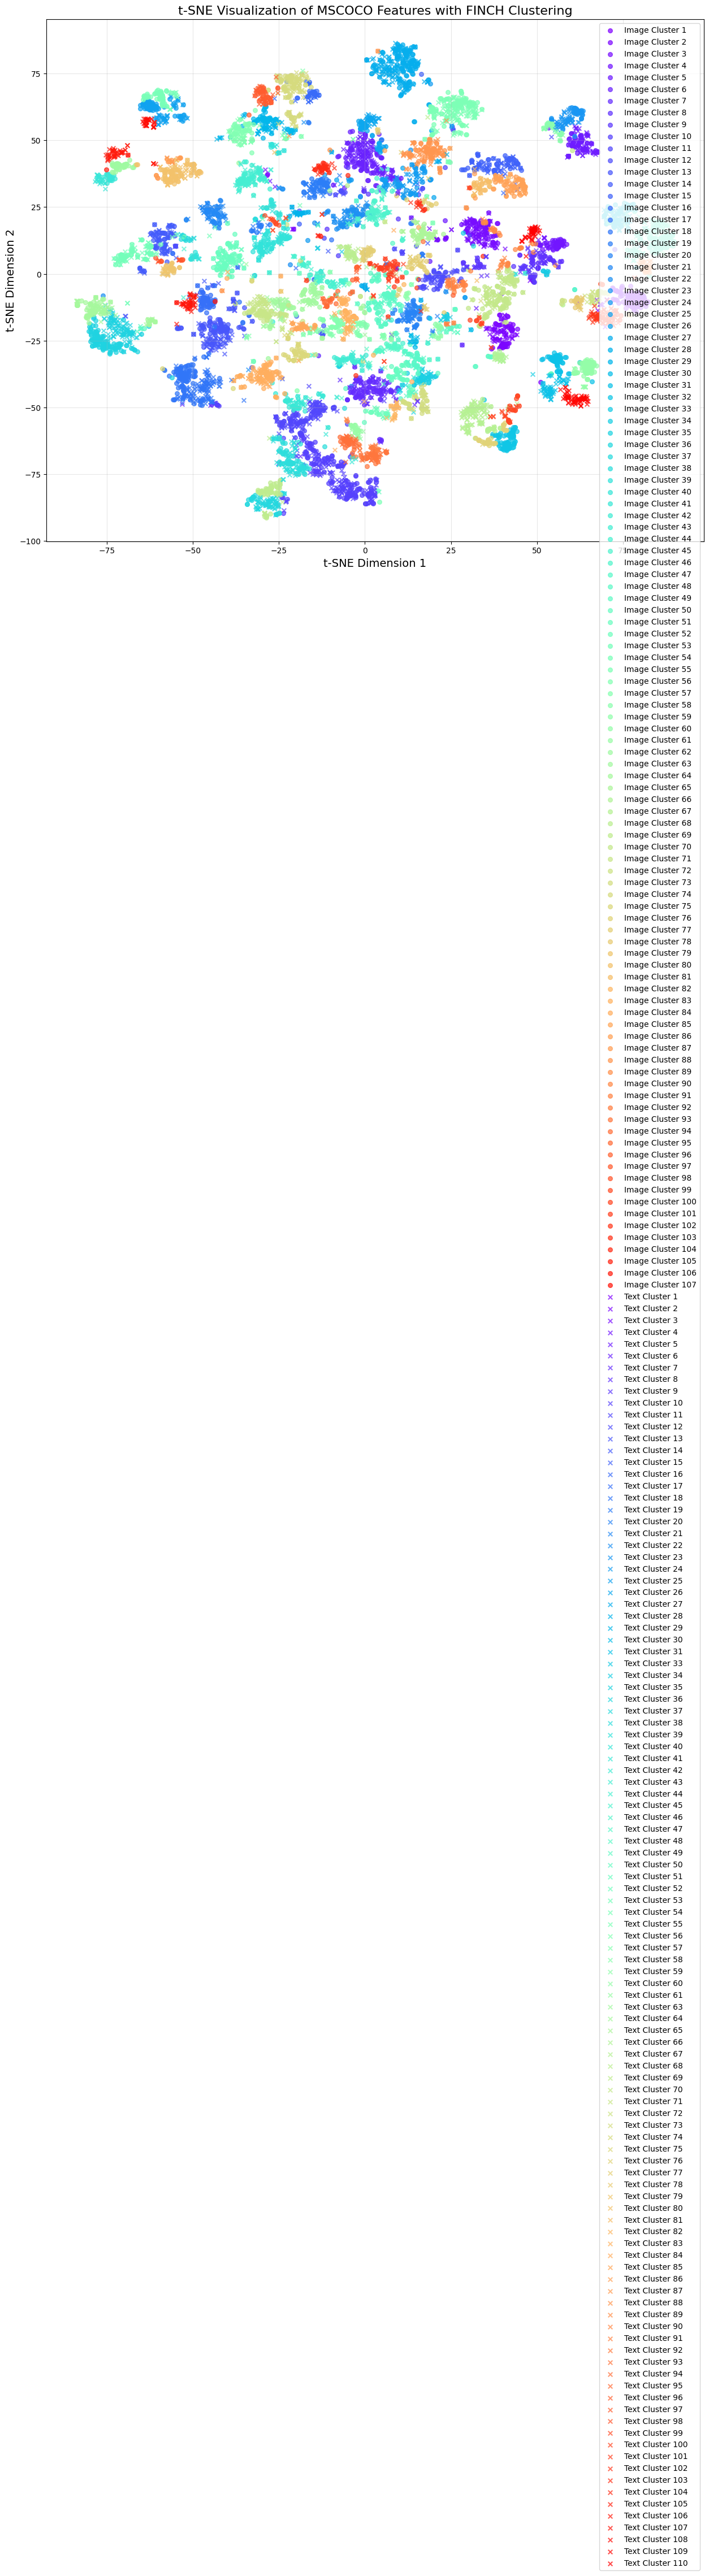

Cluster 1: 111 image features, 10 text features
Cluster 2: 57 image features, 61 text features
Cluster 3: 72 image features, 88 text features
Cluster 4: 59 image features, 7 text features
Cluster 5: 58 image features, 60 text features
Cluster 6: 113 image features, 104 text features
Cluster 7: 82 image features, 74 text features
Cluster 8: 36 image features, 32 text features
Cluster 9: 34 image features, 35 text features
Cluster 10: 151 image features, 156 text features
Cluster 11: 80 image features, 84 text features
Cluster 12: 55 image features, 56 text features
Cluster 13: 103 image features, 87 text features
Cluster 14: 50 image features, 58 text features
Cluster 15: 63 image features, 65 text features
Cluster 16: 22 image features, 20 text features
Cluster 17: 66 image features, 6 text features
Cluster 18: 115 image features, 123 text features
Cluster 19: 57 image features, 64 text features
Cluster 20: 49 image features, 41 text features
Cluster 21: 46 image features, 47 text feat

In [22]:
from finch import FINCH
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Concatenate image and text features
combined_feats = np.concatenate((image_features, text_features), axis=0)

# Apply FINCH clustering
print("Running FINCH clustering...")
cluster, num_cluster, req_cluster = FINCH(combined_feats)

print(cluster)
# Use the first partition level (change index to use different levels)
partition_level = 2
cluster_labels = cluster[:, partition_level]
n_clusters = len(np.unique(cluster_labels))
print(f"FINCH found {n_clusters} clusters at partition level {partition_level}")

# Separate image and text cluster labels
image_labels = cluster_labels[:image_features.shape[0]]
text_labels = cluster_labels[image_features.shape[0]:]

# Apply t-SNE for dimensionality reduction
print("Performing t-SNE dimensionality reduction...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_results = tsne.fit_transform(combined_feats)

# Split the results for image and text features
image_tsne = tsne_results[:image_features.shape[0]]
text_tsne = tsne_results[image_features.shape[0]:]

# Create a colormap for clusters
colors = plt.cm.rainbow(np.linspace(0, 1, n_clusters))

# Create visualization
plt.figure(figsize=(15, 12))

# Plot image features with cluster colors
for i in range(n_clusters):
    idx = np.where(image_labels == i)[0]
    if len(idx) > 0:
        plt.scatter(image_tsne[idx, 0], image_tsne[idx, 1], 
                   color=colors[i], marker='o', 
                   label=f'Image Cluster {i+1}',
                   alpha=0.7, s=30)

# Plot text features with cluster colors
for i in range(n_clusters):
    idx = np.where(text_labels == i)[0]
    if len(idx) > 0:
        plt.scatter(text_tsne[idx, 0], text_tsne[idx, 1], 
                   color=colors[i], marker='x', 
                   label=f'Text Cluster {i+1}',
                   alpha=0.7, s=30)

# Add labels and title
plt.title('t-SNE Visualization of MSCOCO Features with FINCH Clustering', fontsize=16)
plt.xlabel('t-SNE Dimension 1', fontsize=14)
plt.ylabel('t-SNE Dimension 2', fontsize=14)

# Optimize legend display (show each cluster once)
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='upper right', fontsize=10)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print statistics for each cluster
for i in range(n_clusters):
    img_count = np.sum(image_labels == i)
    txt_count = np.sum(text_labels == i)
    print(f"Cluster {i+1}: {img_count} image features, {txt_count} text features")

正在对特征向量进行同态加密...
计算原始数据的余弦相似度矩阵...
计算加密数据的余弦相似度矩阵...
总计算耗时: 0.37 秒
同态加密前后余弦相似度最大差异: 0.0000005983
同态加密前后余弦相似度平均差异: 0.0000000155


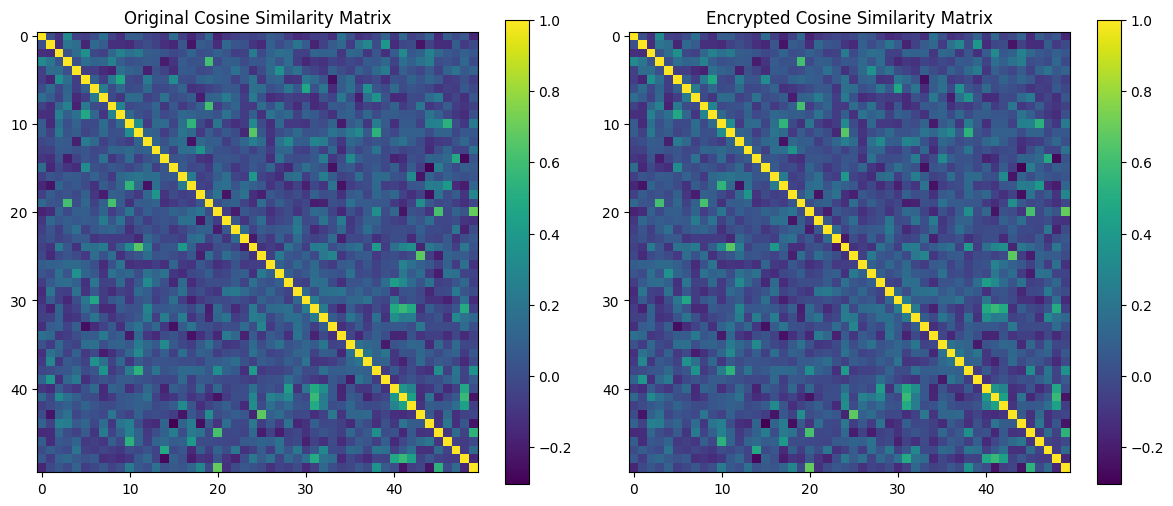

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import time

def homomorphic_encryption(features, seed=42):
    
    np.random.seed(seed)
    
    # 获取特征维度
    n_features = features.shape[1]
    
    # 生成随机矩阵
    random_matrix = np.random.randn(n_features, n_features)
    
    # 使用QR分解获得正交矩阵 (旋转矩阵)
    q, r = np.linalg.qr(random_matrix)
    
    # 应用旋转变换 (矩阵乘法)
    encrypted_features = np.dot(features, q)
    
    return encrypted_features, q

# 开始计时
start_time = time.time()

# 对图像和文本特征进行加密
print("正在对特征向量进行同态加密...")
encrypted_features, encryption_matrix = homomorphic_encryption(combined_feats)

# 计算原始特征的余弦相似度矩阵
print("计算原始数据的余弦相似度矩阵...")
original_similarity = cosine_similarity(combined_feats)

# 计算加密后特征的余弦相似度矩阵
print("计算加密数据的余弦相似度矩阵...")
encrypted_similarity = cosine_similarity(encrypted_features)

# 结束计时
elapsed_time = time.time() - start_time
print(f"总计算耗时: {elapsed_time:.2f} 秒")

# 验证两个相似度矩阵的差异
diff = np.abs(original_similarity - encrypted_similarity).max()
mean_diff = np.abs(original_similarity - encrypted_similarity).mean()
print(f"同态加密前后余弦相似度最大差异: {diff:.10f}")
print(f"同态加密前后余弦相似度平均差异: {mean_diff:.10f}")

# 可视化相似度矩阵比较
plt.figure(figsize=(12, 5))

# Select a portion of the data for visualization
n_show = 50
plt.subplot(1, 2, 1)
plt.imshow(original_similarity[:n_show, :n_show], cmap='viridis')
plt.colorbar()
plt.title('Original Cosine Similarity Matrix')

plt.subplot(1, 2, 2)
plt.imshow(encrypted_similarity[:n_show, :n_show], cmap='viridis')
plt.colorbar()
plt.title('Encrypted Cosine Similarity Matrix')

plt.tight_layout()
plt.show()

# 保存加密后的特征（可选）
# np.save('encrypted_img_features.npy', encrypted_image_features)
# np.save('encrypted_txt_features.npy', encrypted_text_features)

计算余弦相似度矩阵...
进行谱聚类...


执行t-SNE降维...


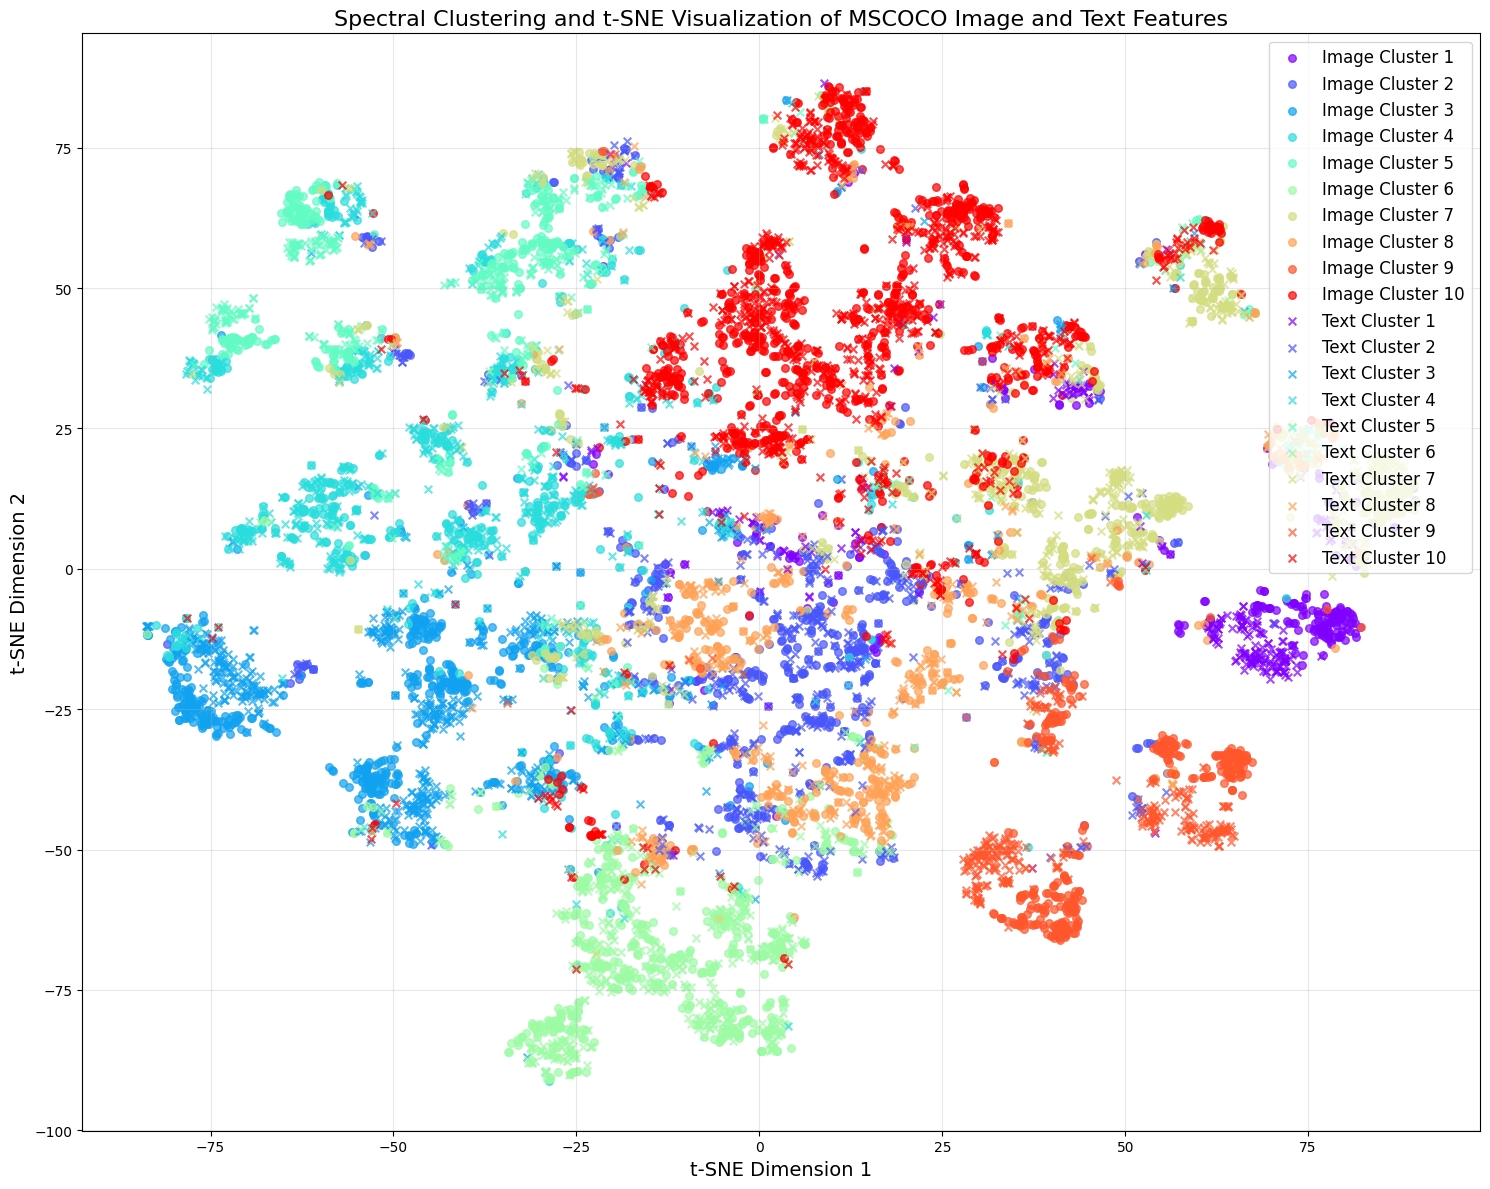

Cluster 1: Contains 250 image features, 282 text features
Cluster 2: Contains 497 image features, 556 text features
Cluster 3: Contains 562 image features, 615 text features
Cluster 4: Contains 605 image features, 554 text features
Cluster 5: Contains 357 image features, 418 text features
Cluster 6: Contains 497 image features, 518 text features
Cluster 7: Contains 554 image features, 559 text features
Cluster 8: Contains 442 image features, 362 text features
Cluster 9: Contains 358 image features, 346 text features
Cluster 10: Contains 878 image features, 790 text features


In [24]:
# 计算余弦相似度矩阵并转换为距离矩阵
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import SpectralClustering
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np

# 计算余弦相似度矩阵
print("计算余弦相似度矩阵...")
similarity_matrix = encrypted_similarity + 1

# 进行谱聚类
print("进行谱聚类...")
n_clusters = 10  # 可以根据需要调整聚类数量
spectral = SpectralClustering(n_clusters=n_clusters, 
                              affinity='precomputed',
                              random_state=42,
                              assign_labels='kmeans')

# 使用相似度矩阵而非距离矩阵作为亲和度矩阵
cluster_labels = spectral.fit_predict(similarity_matrix)

# 使用t-SNE进行降维可视化
print("执行t-SNE降维...")
tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(combined_feats)

# 分离image_features和text_features的t-SNE结果
image_tsne = tsne_results[:image_features.shape[0]]
text_tsne = tsne_results[image_features.shape[0]:]

# 分离image和text的聚类标签
image_labels = cluster_labels[:image_features.shape[0]]
text_labels = cluster_labels[image_features.shape[0]:]

# Create visualization
plt.figure(figsize=(15, 12))

# Create color mapping
colors = plt.cm.rainbow(np.linspace(0, 1, n_clusters))

# Plot image feature points, colored by cluster
for i in range(n_clusters):
    plt.scatter(image_tsne[image_labels == i, 0], 
                image_tsne[image_labels == i, 1],
                color=colors[i], 
                marker='o',
                label=f'Image Cluster {i+1}',
                alpha=0.7, 
                s=30)

# Plot text feature points, colored by cluster and using different markers
for i in range(n_clusters):
    plt.scatter(text_tsne[text_labels == i, 0], 
                text_tsne[text_labels == i, 1],
                color=colors[i], 
                marker='x',
                label=f'Text Cluster {i+1}',
                alpha=0.7, 
                s=30)

# Add title and legend
plt.title('Spectral Clustering and t-SNE Visualization of MSCOCO Image and Text Features', fontsize=16)
plt.xlabel('t-SNE Dimension 1', fontsize=14)
plt.ylabel('t-SNE Dimension 2', fontsize=14)

# Optimize legend display (show each cluster only once)
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='upper right', fontsize=12)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print statistics for each cluster
for i in range(n_clusters):
    img_count = np.sum(image_labels == i)
    txt_count = np.sum(text_labels == i)
    print(f"Cluster {i+1}: Contains {img_count} image features, {txt_count} text features")

In [6]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def calculate_accuracy(image_features, text_features, labels, threshold=0.5):
    # 计算余弦相似度矩阵
    similarity_matrix = cosine_similarity(image_features, text_features)
    
    # 根据阈值判断匹配情况
    predictions = (similarity_matrix > threshold).astype(int)
    
    # 计算准确率
    accuracy = np.mean(predictions == labels)
    
    return accuracy

# 假设image_features和text_features是已经加载好的特征数据
# image_features和text_features的形状应该是 (num_samples, feature_dim)
# labels是一个二维数组，形状为 (num_samples, num_samples)，表示正确的匹配情况（1表示匹配，0表示不匹配）

# 示例数据
num_samples = 5000
feature_dim = 512
labels = np.eye(num_samples)  # 假设每个图像只与一个文本匹配

# 计算准确率
accuracy = calculate_accuracy(image_features, text_features, labels)
print(f"图文匹配准确率: {accuracy * 100:.2f}%")

图文匹配准确率: 99.31%


In [ ]:
# Import the necessary modules for Flickr30k dataset
import os
import pickle
from torch.utils.data import Dataset, DataLoader, Subset
import torch.nn.functional as F
from tqdm import tqdm

class F30kCaptionsCap(Dataset):
    def __init__(self, annFile='dataset_k_split.pkl', split='train',
                 transform=None, target_transform=None):
        self.transform = transform
        self.target_transform = target_transform
        self.data = pickle.load(open(annFile, 'rb'))
        if split not in self.data.keys():
            assert False, f'split wrong {split}'
        self.data = self.data[split]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        data = self.data[index]
        caption = data[1]

        path = data[0].replace('/data/mmdata/Flick30k/flickr30k-images/',
                       '/home/bd/data/zs/data/flickr30k/flickr30k-images/')

        img = Image.open(path).convert('RGB')
        if self.transform is not None:
            img = self.transform(img)

        if self.target_transform is not None:
            target = self.target_transform(caption)[0]
            return img, target, caption
        return img, caption


FLICKR_PATH = 'dataset_k_split.pkl'
flickr30k_dataset = F30kCaptionsCap(FLICKR_PATH, transform=img_preprocess,
                                    target_transform=clip.tokenize)
print(f"Loaded Flickr30k dataset with {len(flickr30k_dataset)} samples")

# Sample a subset of the dataset if it's large
sample_size = min(2000, len(flickr30k_dataset) if 'flickr30k_dataset' in locals() else 0)
if sample_size > 0:
    indices = np.random.choice(len(flickr30k_dataset), sample_size, replace=False)
    flickr30k_subset = Subset(flickr30k_dataset, indices)
    
    # Create a DataLoader for efficient batching
    batch_size = 32
    dataloader = DataLoader(flickr30k_subset, batch_size=batch_size, shuffle=False)

    # Process the dataset to extract image and text features
    image_features_list = []
    text_features_list = []
    
    combined_model.eval()  # Ensure the model is in evaluation mode
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Processing Flickr30k"):
            images, text_tokens, captions = batch
            
            # Move data to device
            images = images.to(device)
            text_tokens = text_tokens.to(device)
            
            # Get features
            img_feats, txt_feats = combined_model(images, text_tokens)
            
            # Normalize features
            img_feats = F.normalize(img_feats, p=2, dim=1)
            txt_feats = F.normalize(txt_feats, p=2, dim=1)
            
            # Store features
            image_features_list.append(img_feats.cpu().numpy())
            text_features_list.append(txt_feats.cpu().numpy())
    # Concatenate all batches
    flickr_img_features = np.concatenate(image_features_list, axis=0)
    flickr_txt_features = np.concatenate(text_features_list, axis=0)
    
    print(f"Generated features for {flickr_img_features.shape[0]} Flickr30k images and texts")

Loaded Flickr30k dataset with 145000 samples


Processing Flickr30k:   3%|▎         | 2/63 [00:00<00:17,  3.49it/s]

Processing Flickr30k: 100%|██████████| 63/63 [00:16<00:00,  3.78it/s]

Generated features for 2000 Flickr30k images and texts


/mnt/data/software/anaconda/envs/zs_vita/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Performing t-SNE dimensionality reduction...


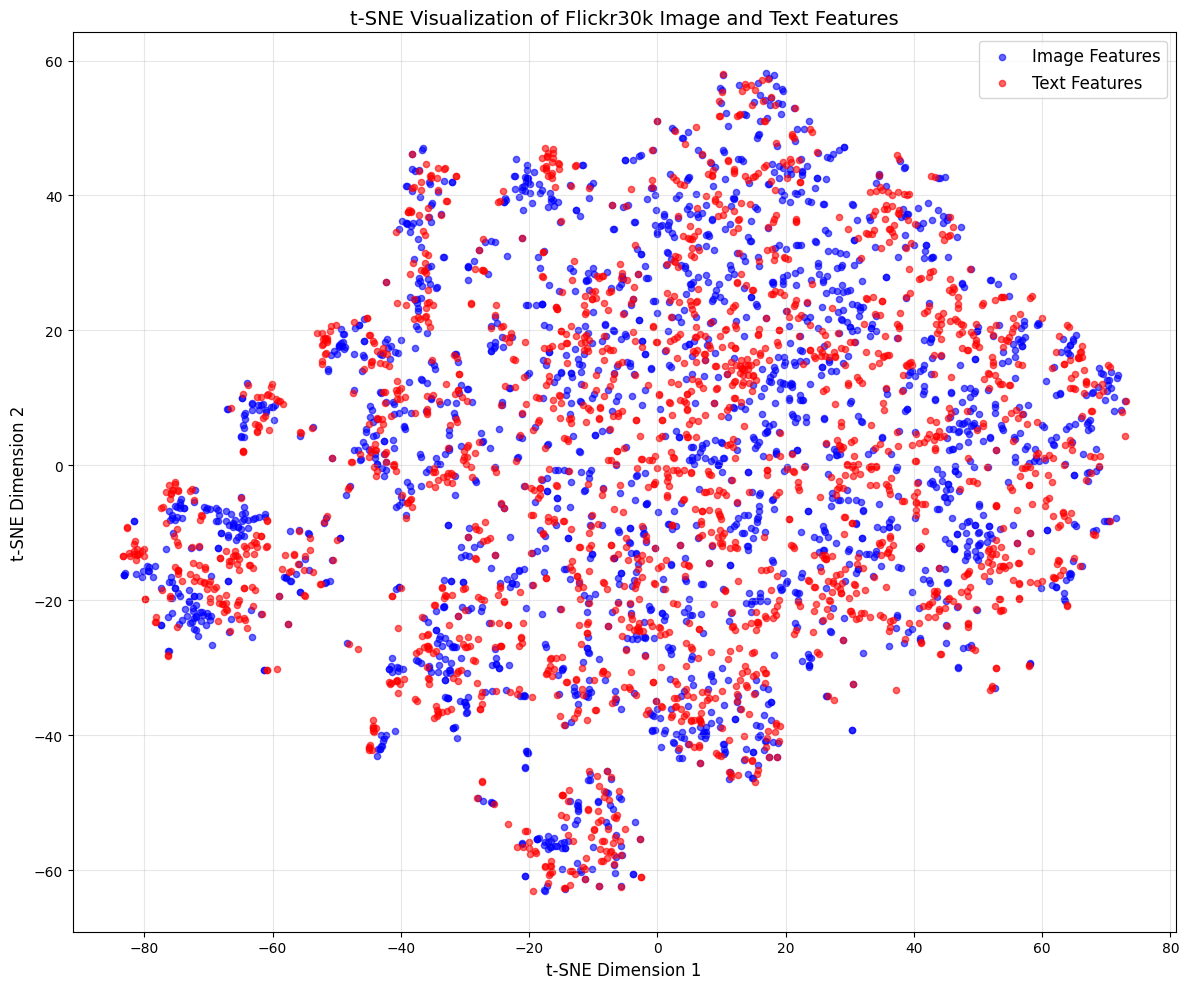

In [8]:
# Visualize Flickr30k image and text features using t-SNE
from matplotlib import pyplot as plt
from sklearn.manifold import TSNE

# Combine image and text features
flickr_combined_feats = np.concatenate((flickr_img_features, flickr_txt_features), axis=0)

# Apply t-SNE dimensionality reduction
print("Performing t-SNE dimensionality reduction...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
flickr_tsne_results = tsne.fit_transform(flickr_combined_feats)

# Split the results back into image and text features
flickr_img_tsne = flickr_tsne_results[:flickr_img_features.shape[0]]
flickr_txt_tsne = flickr_tsne_results[flickr_img_features.shape[0]:]

# Create visualization
plt.figure(figsize=(12, 10))

# Plot image and text embeddings
plt.scatter(flickr_img_tsne[:, 0], flickr_img_tsne[:, 1], c='blue', label='Image Features', alpha=0.6, s=20)
plt.scatter(flickr_txt_tsne[:, 0], flickr_txt_tsne[:, 1], c='red', label='Text Features', alpha=0.6, s=20)

# Add title and legend
plt.title('t-SNE Visualization of Flickr30k Image and Text Features', fontsize=14)
plt.legend(fontsize=12)

# Add axis labels
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)

# Add grid for better readability
plt.grid(alpha=0.3)

# Improve layout
plt.tight_layout()

# Save the visualization
# os.makedirs('visualization_results', exist_ok=True)
# plt.savefig('visualization_results/flickr30k_tsne_visualization.png', dpi=300, bbox_inches='tight')
# print("Visualization saved to 'visualization_results/flickr30k_tsne_visualization.png'")

plt.show()

In [9]:
# Calculate alignment metrics between image and text features
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def calculate_retrieval_metrics(img_features, txt_features):
    """Calculate image-to-text and text-to-image retrieval metrics"""
    # Calculate cosine similarity between all images and texts
    similarity_matrix = cosine_similarity(img_features, txt_features)
    
    # For each image, find the rank of its corresponding text
    i2t_ranks = []
    for i in range(len(img_features)):
        # Get the similarity scores for this image with all texts
        similarities = similarity_matrix[i, :]
        # The ground truth match should be at the same index
        target_similarity = similarities[i]
        # Count how many texts are more similar to this image than the ground truth
        rank = np.sum(similarities > target_similarity) + 1
        i2t_ranks.append(rank)
    
    # For each text, find the rank of its corresponding image
    t2i_ranks = []
    for i in range(len(txt_features)):
        # Get the similarity scores for this text with all images
        similarities = similarity_matrix[:, i]
        # The ground truth match should be at the same index
        target_similarity = similarities[i]
        # Count how many images are more similar to this text than the ground truth
        rank = np.sum(similarities > target_similarity) + 1
        t2i_ranks.append(rank)
    
    # Calculate metrics
    i2t_ranks = np.array(i2t_ranks)
    t2i_ranks = np.array(t2i_ranks)
    
    # Recall@K metrics
    metrics = {
        'i2t_r1': np.mean(i2t_ranks <= 1) * 100,
        'i2t_r5': np.mean(i2t_ranks <= 5) * 100,
        'i2t_r10': np.mean(i2t_ranks <= 10) * 100,
        't2i_r1': np.mean(t2i_ranks <= 1) * 100,
        't2i_r5': np.mean(t2i_ranks <= 5) * 100,
        't2i_r10': np.mean(t2i_ranks <= 10) * 100,
        'i2t_median_rank': np.median(i2t_ranks),
        't2i_median_rank': np.median(t2i_ranks)
    }
    
    return metrics

# Calculate and print metrics
metrics = calculate_retrieval_metrics(flickr_img_features, flickr_txt_features)

print("Flickr30k Retrieval Performance:")
print(f"Image-to-Text:")
print(f"  Recall@1: {metrics['i2t_r1']:.2f}%")
print(f"  Recall@5: {metrics['i2t_r5']:.2f}%")
print(f"  Recall@10: {metrics['i2t_r10']:.2f}%")
print(f"  Median Rank: {metrics['i2t_median_rank']}")
print(f"Text-to-Image:")
print(f"  Recall@1: {metrics['t2i_r1']:.2f}%")
print(f"  Recall@5: {metrics['t2i_r5']:.2f}%")
print(f"  Recall@10: {metrics['t2i_r10']:.2f}%")
print(f"  Median Rank: {metrics['t2i_median_rank']}")

Flickr30k Retrieval Performance:
Image-to-Text:
  Recall@1: 39.80%
  Recall@5: 70.70%
  Recall@10: 79.75%
  Median Rank: 2.0
Text-to-Image:
  Recall@1: 41.40%
  Recall@5: 71.00%
  Recall@10: 80.35%
  Median Rank: 2.0


In [10]:
# Process the dataset to extract image and text features
original_image_features_list = []
original_text_features_list = []

combined_model.eval()  # Ensure the model is in evaluation mode

with torch.no_grad():
    for batch in tqdm(dataloader, desc="Processing Flickr30k"):
        images, text_tokens, captions = batch
        
        # Move data to device
        images = images.to(device)
        text_tokens = text_tokens.to(device)
        
        # Get features
        img_feats = clip_model.encode_image(images)
        txt_feats = clip_model.encode_text(text_tokens)
        
        # Normalize features
        img_feats = F.normalize(img_feats, p=2, dim=1)
        txt_feats = F.normalize(txt_feats, p=2, dim=1)
        
        # Store features
        original_image_features_list.append(img_feats.cpu().numpy())
        original_text_features_list.append(txt_feats.cpu().numpy())
        
# Concatenate all batches
original_flickr_img_features = np.concatenate(original_image_features_list, axis=0)
original_flickr_txt_features = np.concatenate(original_text_features_list, axis=0)

original_metrics = calculate_retrieval_metrics(original_flickr_img_features, original_flickr_txt_features)
print("Flickr30k Retrieval Performance:")
print(f"Image-to-Text:")
print(f"  Recall@1: {original_metrics['i2t_r1']:.2f}%")
print(f"  Recall@5: {original_metrics['i2t_r5']:.2f}%")
print(f"  Recall@10: {original_metrics['i2t_r10']:.2f}%")
print(f"  Median Rank: {original_metrics['i2t_median_rank']}")
print(f"Text-to-Image:")
print(f"  Recall@1: {original_metrics['t2i_r1']:.2f}%")
print(f"  Recall@5: {original_metrics['t2i_r5']:.2f}%")
print(f"  Recall@10: {original_metrics['t2i_r10']:.2f}%")
print(f"  Median Rank: {original_metrics['t2i_median_rank']}")

Processing Flickr30k: 100%|██████████| 63/63 [00:17<00:00,  3.66it/s]

Flickr30k Retrieval Performance:
Image-to-Text:
  Recall@1: 51.75%
  Recall@5: 79.35%
  Recall@10: 87.30%
  Median Rank: 1.0
Text-to-Image:
  Recall@1: 49.00%
  Recall@5: 77.00%
  Recall@10: 84.70%
  Median Rank: 2.0


In [2]:
import os
import pickle
# Reload the dataset from local files
dataset_list = []
for file in os.listdir("/home/bd/data/zs/FedMMDP/data/full_dataset/dataset1"):
    if file.endswith(".pkl"):
        dataset_path = os.path.join("/home/bd/data/zs/FedMMDP/data/full_dataset/dataset1", file)
        print(f"Loading dataset from {dataset_path}")
        with open(dataset_path, "rb") as f:
            imgcap_dataset = pickle.load(f)
            dataset_list.append(imgcap_dataset)

print("Dataset reloaded from local files.")

Loading dataset from /home/bd/data/zs/FedMMDP/data/full_dataset/dataset1/imgcap_dataset0.pkl
Loading dataset from /home/bd/data/zs/FedMMDP/data/full_dataset/dataset1/imgcap_dataset1.pkl
Loading dataset from /home/bd/data/zs/FedMMDP/data/full_dataset/dataset1/imgcap_dataset2.pkl
Loading dataset from /home/bd/data/zs/FedMMDP/data/full_dataset/dataset1/imgcap_dataset3.pkl
Loading dataset from /home/bd/data/zs/FedMMDP/data/full_dataset/dataset1/imgcap_dataset4.pkl
Loading dataset from /home/bd/data/zs/FedMMDP/data/full_dataset/dataset1/imgcap_dataset5.pkl
Dataset reloaded from local files.


In [3]:
from datasets import Dataset, concatenate_datasets
for i in range(len(dataset_list)):
    dataset_list[i] = Dataset.from_list(dataset_list[i])
full_dataset = concatenate_datasets(dataset_list)
print(full_dataset)

Dataset({
    features: ['class', 'id', 'recaption_short', 'cap_tokens', 'processed_img'],
    num_rows: 10146
})


In [4]:
from collections import Counter
class_counts = Counter(sample["class"] for sample in full_dataset)

popular_classes = {cls: count for cls, count in class_counts.items() if count >= 100}
dataset = full_dataset.filter(lambda x: x["class"] in popular_classes)
print(f"Filtered dataset size: {len(dataset)}")

print("Class:{}, Count:{}".format(popular_classes.keys(), popular_classes.values()))

print("Class_size:{}".format(len(popular_classes)))

Filter: 100%|██████████| 10146/10146 [07:45<00:00, 21.81 examples/s]

Filtered dataset size: 10137
Class:dict_keys(['benthos', 'cell', 'person, individual, someone, somebody, mortal, soul', 'animal, animate_being, beast, brute, creature, fauna', 'plant, flora, plant_life', 'food, nutrient', 'artifact, artefact', 'hop', 'check-in']), Count:dict_values([1264, 1251, 1242, 1570, 1271, 1272, 1249, 811, 207])
Class_size:9


In [9]:
full_dataset.to_iterable_dataset()

IterableDataset({
    features: ['class', 'id', 'recaption_short', 'cap_tokens', 'processed_img'],
    num_shards: 1
})

In [ ]:
full_dataset.save_to_disk('data/full_dataset')

Saving the dataset (21/21 shards): 100%|██████████| 16908/16908 [01:24<00:00, 200.46 examples/s]


In [4]:
from datasets import load_from_disk
full_dataset = load_from_disk('data/full_dataset')

In [6]:
from torch.utils.data import DataLoader
from tqdm import tqdm
import torch

def collate_fn(batch):
    """
    自定义批处理函数，确保图像和文本数据被正确转换为张量
    """
    # 将所有样本的图像和文本数据提取出来
    processed_imgs = []
    cap_tokens = []
    other_data = {}
    
    for item in batch:
        # 处理图像数据
        if isinstance(item["processed_img"], torch.Tensor):
            processed_imgs.append(item["processed_img"])
        else:
            processed_imgs.append(torch.tensor(item["processed_img"], dtype=torch.float))
        
        # 处理文本数据
        if isinstance(item["cap_tokens"], torch.Tensor):
            cap_tokens.append(item["cap_tokens"])
        else:
            cap_tokens.append(torch.tensor(item["cap_tokens"], dtype=torch.long))
        
        # 收集其他数据字段
        for k, v in item.items():
            if k not in ["processed_img", "cap_tokens"]:
                if k not in other_data:
                    other_data[k] = []
                other_data[k].append(v)
    
    # 将列表转换为批次张量
    result = {
        "processed_img": torch.stack(processed_imgs),
        "cap_tokens": torch.stack(cap_tokens)
    }
    
    # 添加其他数据字段
    for k, v in other_data.items():
        result[k] = v
    
    return result

dataloader = DataLoader(full_dataset, batch_size=32, collate_fn=collate_fn)
with torch.no_grad():
    images_features_list = []
    texts_features_list = []
    for batch in tqdm(dataloader):
        # Get the image and text data
        images = batch["processed_img"].to(device)
        texts = batch["cap_tokens"].to(device)

        # Encode the images and texts
        image_features, text_features = combined_model(images, texts)

        # Normalize the features
        image_features /= image_features.norm(dim=-1, keepdim=True)
        text_features /= text_features.norm(dim=-1, keepdim=True)
        
        # Store the features
        images_features_list.append(image_features.cpu().numpy())
        texts_features_list.append(text_features.cpu().numpy())
    
    imgcap_images_features = np.concatenate(images_features_list, axis=0)
    imgcap_texts_features = np.concatenate(texts_features_list, axis=0)

100%|██████████| 529/529 [13:51<00:00,  1.57s/it]


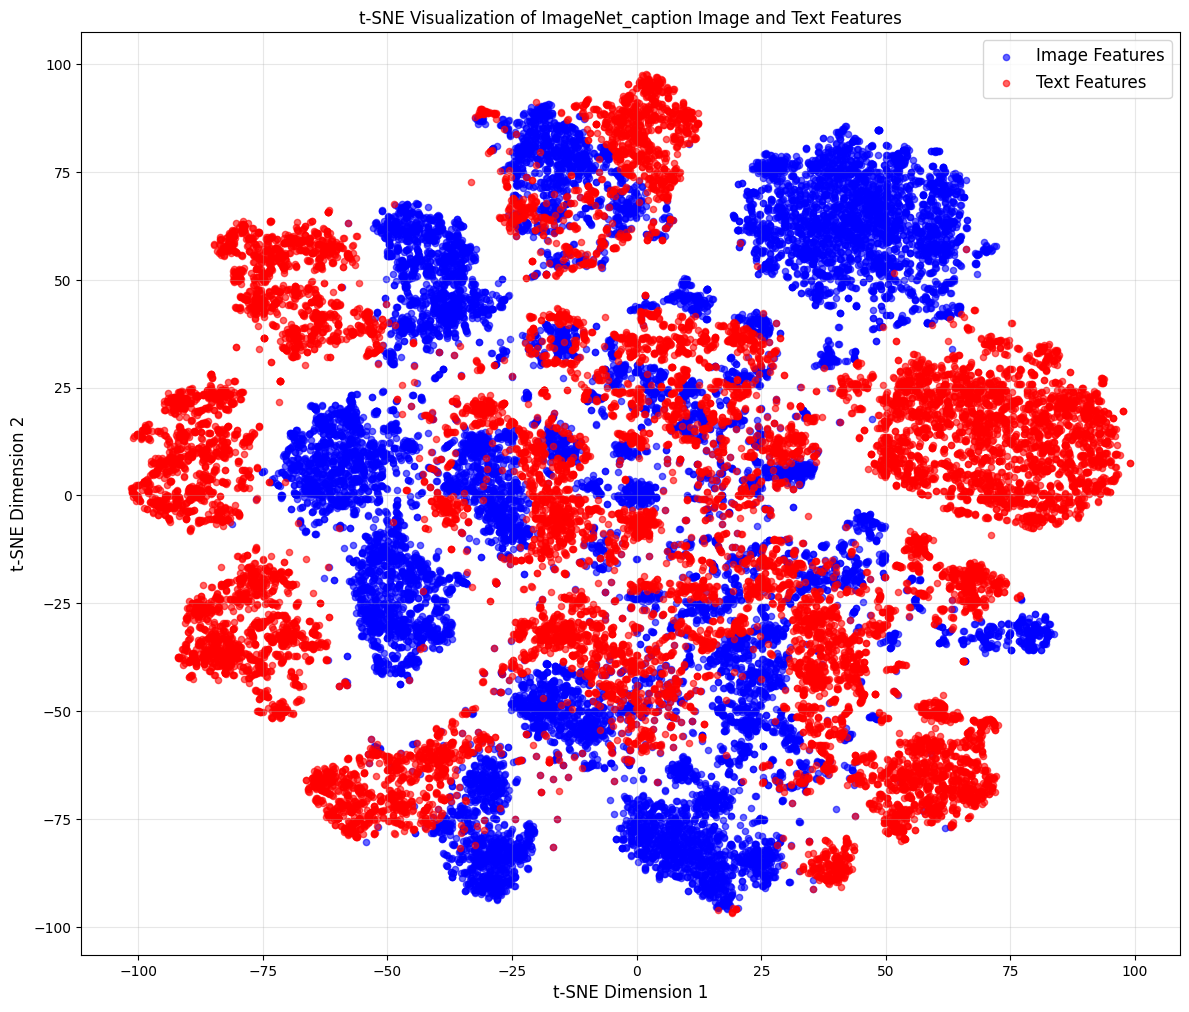

In [7]:
from matplotlib import pyplot as plt
from sklearn.manifold import TSNE

# 将image_features和text_features合并为一个数组
combined_feats = np.concatenate((imgcap_images_features, imgcap_texts_features), axis=0)
# combined_feats = np.concatenate((tmp_img_embeds.cpu(), tmp_txt_embeds.cpu()), axis=0)

# 创建t-SNE模型并拟合数据
tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(combined_feats)

# 分离image_features和text_features的t-SNE结果
image_tsne = tsne_results[:imgcap_images_features.shape[0]]
text_tsne = tsne_results[imgcap_images_features.shape[0]:]

# 可视化结果

# Create visualization
plt.figure(figsize=(12, 10))
plt.scatter(image_tsne[:, 0], image_tsne[:, 1], c='blue', label='Image Features', alpha=0.6, s=20)
plt.scatter(text_tsne[:, 0], text_tsne[:, 1], c='red', label='Text Features', alpha=0.6, s=20)
plt.legend()
plt.legend(fontsize=12)

# Add axis labels
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)

# Add grid for better readability
plt.grid(alpha=0.3)

# Improve layout
plt.tight_layout()
plt.title('t-SNE Visualization of ImageNet_caption Image and Text Features')
plt.show()

In [2]:
import os
import ijson
import json

root_directory = "/home/bd/data/zs/data/MedTrinity-25M/25M_accessible/"

# JSONL 文件是多顶层 JSON 对象（每行一个对象）。优先用 ijson 的 multiple_values，
# 若环境不支持则回退到逐行 json.loads。
max_print_per_file = 3  # 防止输出过多，仅示例打印前几个对象

def iter_jsonl(f):
    try:
        # ijson 支持多顶层对象的流式解析
        yield from ijson.items(f, "", multiple_values=True)
    except TypeError:
        # 旧版 ijson 无 multiple_values 参数，回退到逐行解析
        f.seek(0)
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                yield json.loads(line)
            except json.JSONDecodeError:
                continue

for dirpath, dirnames, filenames in os.walk(root_directory):
    for filename in filenames:
        if filename.startswith("metadata") and filename.endswith(".jsonl"):
            file_path = os.path.join(dirpath, filename)
            try:
                with open(file_path, "r", encoding="utf-8") as f:
                    printed = 0
                    for obj in iter_jsonl(f):
                        print(obj)
                        printed += 1
                        if printed >= max_print_per_file:
                            break
            except Exception as e:
                print(f"Error reading {file_path}: {e}")

{'id': '900ed35c-2c1e-11ef-8f69-f02f74942466', 'file_name': 'seg_train_2782_a_2-covid-19 infection.nii-36.jpg', 'caption': 'The image is a high-resolution computed tomography (HRCT) scan of the chest, showing the lungs, which are the primary organs visible. The scan cuts through the lower lobes of the lungs, with the heart and parts of the rib cage also visible. The region of interest, located in the lower-middle left-center of the image, shows an abnormality in the lung tissue, characterized by a change in texture and density, which is indicative of a COVID-19 infection. This abnormal area is situated at the periphery of the lung tissue, likely in the inferior lobe given its position. The affected area may be related to the surrounding lung tissue, potentially indicating a localized infection that could spread or be a result of spread from adjacent regions. The presence of this abnormality suggests a pathological process, possibly related to the ground-glass opacities or consolidation

In [3]:
# 抽取每个 metadata*.jsonl 的 100 条样本到 submetadata.jsonl，并重组为 Hugging Face 数据集
import os
import json
import ijson
from datasets import Dataset, Features, Image as HFImage, Value
from tqdm import tqdm

root_directory = "/home/bd/data/zs/data/MedTrinity-25M/25M_accessible/"
output_dataset_dir = "/home/bd/data/zs/FedMMDP/data/medtrinity_subdataset"  # 数据集保存路径
samples_per_metadata = 100

# 兼容 JSONL 的多顶层对象流式解析

def iter_jsonl(f):
    try:
        yield from ijson.items(f, "", multiple_values=True)
    except TypeError:
        f.seek(0)
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                yield json.loads(line)
            except json.JSONDecodeError:
                continue

# 解析 caption 字段的优先级

def get_caption(obj):
    for key in ["caption", "text", "description", "report", "label"]:
        if key in obj and isinstance(obj[key], str) and obj[key].strip():
            return obj[key].strip()
    return None

# 尝试定位图像路径

def find_image_path(dirpath, file_name):
    candidates = []
    if isinstance(file_name, str):
        candidates.append(os.path.join(dirpath, file_name))
        candidates.append(os.path.join(root_directory, file_name))
        # 常见子目录尝试
        for sub in ["images", "imgs", "image", "img"]:
            candidates.append(os.path.join(dirpath, sub, file_name))
            candidates.append(os.path.join(root_directory, sub, file_name))
    for p in candidates:
        if os.path.exists(p):
            return p
    # 若 file_name 是绝对路径
    if isinstance(file_name, str) and os.path.isabs(file_name) and os.path.exists(file_name):
        return file_name
    return None

all_examples = []

metadata_files = []
for dirpath, dirnames, filenames in os.walk(root_directory):
    for filename in filenames:
        if filename.startswith("metadata") and filename.endswith(".jsonl"):
            metadata_files.append(os.path.join(dirpath, filename))

print(f"发现 {len(metadata_files)} 个 metadata.jsonl 文件")

for meta_path in tqdm(metadata_files, desc="Processing metadata files"):
    dirpath = os.path.dirname(meta_path)
    submeta_path = os.path.join(dirpath, "submetadata.jsonl")

    # 抽样 100 条到 submetadata.jsonl（覆盖写入）
    collected = []
    try:
        with open(meta_path, "r", encoding="utf-8") as f:
            for obj in iter_jsonl(f):
                collected.append(obj)
                if len(collected) >= samples_per_metadata:
                    break
    except Exception as e:
        print(f"[WARN] 跳过 {meta_path}: {e}")
        continue

    try:
        with open(submeta_path, "w", encoding="utf-8") as wf:
            for obj in collected:
                wf.write(json.dumps(obj, ensure_ascii=False) + "\n")
    except Exception as e:
        print(f"[WARN] 写入 {submeta_path} 失败: {e}")
        continue

    # 基于 submetadata.jsonl 生成样本：id、image、caption、source
    try:
        with open(submeta_path, "r", encoding="utf-8") as sf:
            idx = 0
            for line in sf:
                try:
                    obj = json.loads(line)
                except json.JSONDecodeError:
                    continue
                file_name = obj.get("file_name")
                img_path = find_image_path(dirpath, file_name)
                caption = get_caption(obj)
                source = obj.get("source") or os.path.basename(dirpath) or "unknown"

                # 跳过无图像或无 caption 的样本（如需要可放宽条件）
                if not img_path or not os.path.exists(img_path):
                    continue
                if caption is None:
                    continue

                ex_id = obj.get("id")
                if ex_id is None:
                    ex_id = f"{os.path.basename(dirpath)}-{idx}"
                idx += 1

                all_examples.append({
                    "id": str(ex_id),
                    "image": img_path,
                    "caption": caption,
                    "source": str(source)
                })
    except Exception as e:
        print(f"[WARN] 读取 {submeta_path} 失败: {e}")
        continue

print(f"可用样本总数: {len(all_examples)}")

# 构建并保存 Hugging Face 数据集
features = Features({
    "id": Value("string"),
    "image": HFImage(),
    "caption": Value("string"),
    "source": Value("string"),
})

dataset = Dataset.from_list(all_examples, features=features)
os.makedirs(os.path.dirname(output_dataset_dir), exist_ok=True)
dataset.save_to_disk(output_dataset_dir)
print(f"数据集已保存到: {output_dataset_dir}")

/mnt/data/software/anaconda/envs/zs_vita/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


发现 128 个 metadata.jsonl 文件


Processing metadata files: 100%|██████████| 128/128 [01:01<00:00,  2.09it/s]


可用样本总数: 11807


Saving the dataset (2/2 shards): 100%|██████████| 11807/11807 [06:45<00:00, 29.13 examples/s]

数据集已保存到: /home/bd/data/zs/FedMMDP/data/medtrinity_subdataset


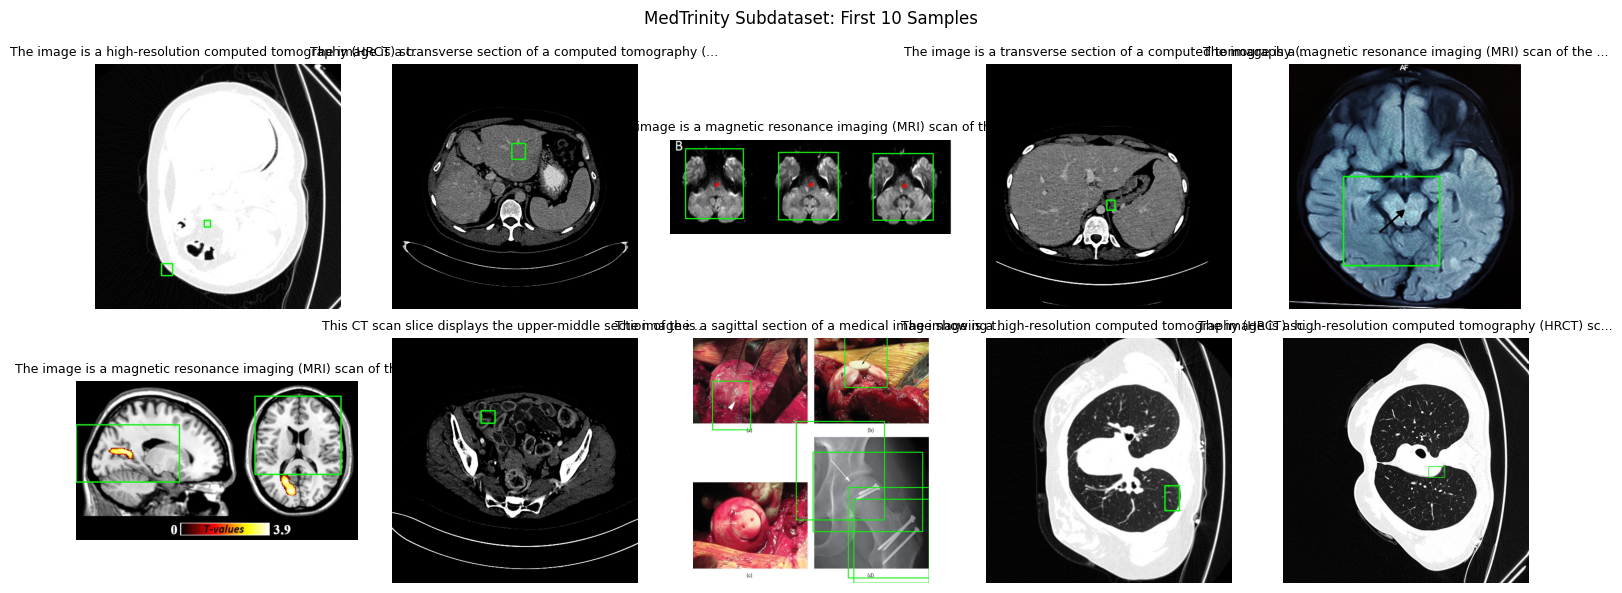

显示 10 条样本，数据集大小: 11807


In [5]:
# 快速可视化前10张图片与caption（确保图像列解码）
from datasets import load_from_disk, Image as HFImage
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import os

dataset_dir = "/home/bd/data/zs/FedMMDP/data/medtrinity_subdataset"

try:
    ds = load_from_disk(dataset_dir)
    # 强制将 image 列设为可解码的 HF Image
    ds = ds.cast_column("image", HFImage(decode=True))
    n = min(10, len(ds))
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()

    for ax in axes:
        ax.axis('off')

    shown = 0
    i = 0
    while shown < n and i < len(ds):
        ex = ds[i]
        i += 1
        img = ex.get("image")
        caption = ex.get("caption", "")

        img_to_show = None
        # HF Image decode=True 默认返回 PIL.Image.Image
        if isinstance(img, Image.Image):
            img_to_show = img
        elif isinstance(img, dict):
            # 可能返回 {'path': ..., 'array': np.ndarray}
            p = img.get("path")
            arr = img.get("array")
            if arr is not None:
                # array 可能是 CHW 或 HWC；尝试转换为 HWC
                arr_np = np.array(arr)
                if arr_np.ndim == 3 and arr_np.shape[0] in (1,3):
                    arr_np = np.transpose(arr_np, (1, 2, 0))
                img_to_show = arr_np
            elif p and os.path.exists(p):
                try:
                    img_to_show = Image.open(p).convert("RGB")
                except Exception:
                    img_to_show = None
        elif isinstance(img, str) and os.path.exists(img):
            try:
                img_to_show = Image.open(img).convert("RGB")
            except Exception:
                img_to_show = None

        if img_to_show is None:
            continue

        axes[shown].imshow(img_to_show)
        if isinstance(caption, str):
            short_cap = caption.strip()
            if len(short_cap) > 60:
                short_cap = short_cap[:60] + "..."
            axes[shown].set_title(short_cap, fontsize=9)
        axes[shown].axis('off')
        shown += 1

    plt.suptitle("MedTrinity Subdataset: First 10 Samples", fontsize=12)
    plt.tight_layout()
    plt.show()
    print(f"显示 {shown} 条样本，数据集大小: {len(ds)}")
except Exception as e:
    print(f"加载或可视化失败: {e}")

Filter: 100%|██████████| 11807/11807 [00:39<00:00, 296.78 examples/s]


Generated features for 5000 MedTrinity images and texts


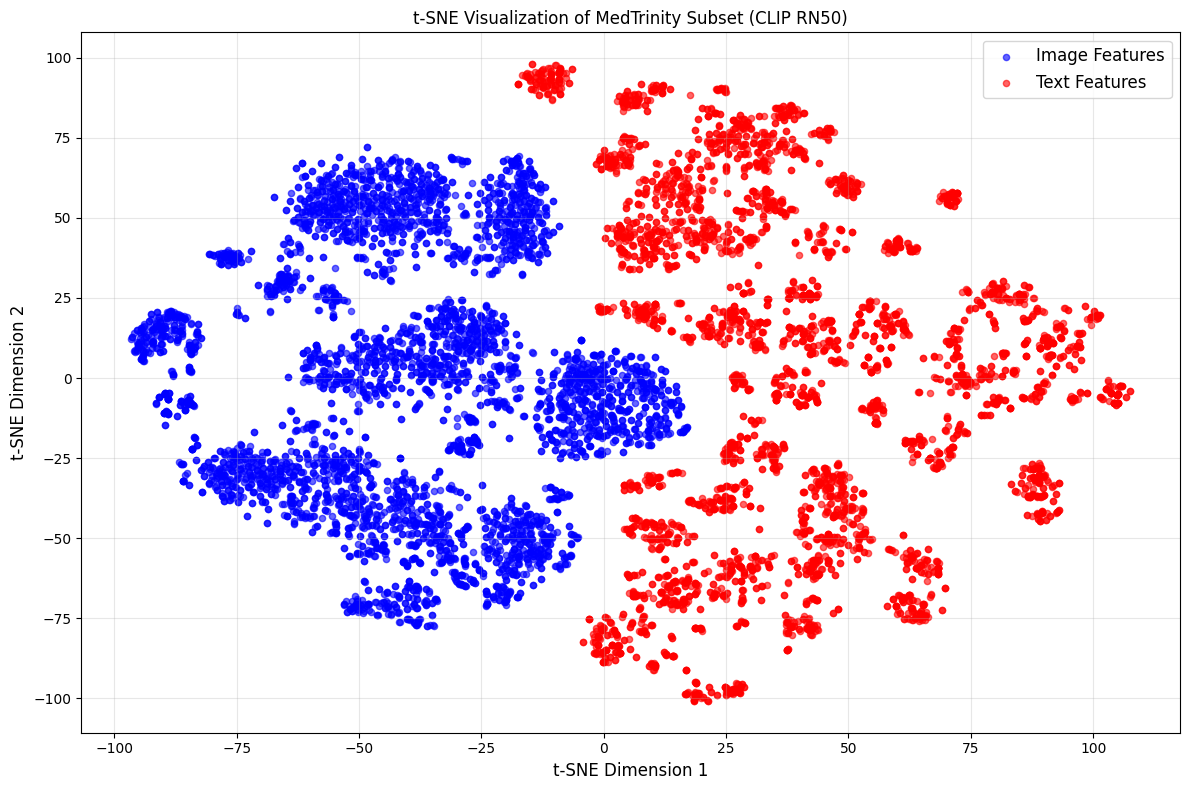

In [ ]:
# 使用已构建的数据集进行子集编码与 t-SNE 可视化
from datasets import load_from_disk, Image as HFImage
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import clip
import torch
import numpy as np
from PIL import Image

# 设备与模型
device = "cuda" if torch.cuda.is_available() else "cpu"
clip_model, img_preprocess = clip.load("RN50", device=device)

# 加载保存的数据集并确保图像可解码
dataset_dir = "/home/bd/data/zs/FedMMDP/data/medtrinity_subdataset"
ds = load_from_disk(dataset_dir)
ds = ds.cast_column("image", HFImage(decode=True))

# 过滤掉缺失或空 caption 的样本
def has_caption(ex):
    cap = ex.get("caption", "")
    return isinstance(cap, str) and len(cap.strip()) > 0

ds = ds.filter(has_caption)

# 选择子集（最多 5000 条）
subset_size = min(5000, len(ds))
samples = ds.shuffle(seed=42).select(range(subset_size))

# 预处理图像与收集文本
images, captions = [], []
for sample in samples:
    img = sample["image"]
    # HFImage(decode=True) 返回 PIL.Image
    if isinstance(img, Image.Image):
        img_tensor = img_preprocess(img.convert("RGB")).unsqueeze(0).to(device)
        images.append(img_tensor)
        captions.append(sample["caption"])  # 已过滤保障非空

# 批量编码图像与文本
with torch.no_grad():
    image_features_list = []
    text_features_list = []
    batch_size = 32
    for i in range(0, len(images), batch_size):
        end = min(i + batch_size, len(images))
        batch_imgs = torch.cat(images[i:end])
        batch_text = clip.tokenize(captions[i:end], truncate=True).to(device)
        img_feats = clip_model.encode_image(batch_imgs).float()
        txt_feats = clip_model.encode_text(batch_text).float()
        # 归一化
        img_feats = img_feats / img_feats.norm(dim=-1, keepdim=True)
        txt_feats = txt_feats / txt_feats.norm(dim=-1, keepdim=True)
        image_features_list.append(img_feats.cpu().numpy())
        text_features_list.append(txt_feats.cpu().numpy())

    medtrinity_img_features = np.concatenate(image_features_list, axis=0)
    medtrinity_txt_features = np.concatenate(text_features_list, axis=0)

print(f"Generated features for {medtrinity_img_features.shape[0]} MedTrinity images and texts")

# 合并图像与文本特征
combined_feats = np.concatenate((medtrinity_img_features, medtrinity_txt_features), axis=0)

# t-SNE 可视化
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_results = tsne.fit_transform(combined_feats)
plt.figure(figsize=(12, 8))

# 分离图像与文本的 t-SNE 结果
image_tsne = tsne_results[:medtrinity_img_features.shape[0]]
text_tsne = tsne_results[medtrinity_img_features.shape[0]:]

plt.scatter(image_tsne[:, 0], image_tsne[:, 1], c='blue', label='Image Features', alpha=0.6, s=20)
plt.scatter(text_tsne[:, 0], text_tsne[:, 1], c='red', label='Text Features', alpha=0.6, s=20)
plt.legend(fontsize=12)
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.title('t-SNE Visualization of MedTrinity Subset (CLIP RN50)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

/mnt/data/software/anaconda/envs/zs_vita/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 10000 samples in 0.003s...
[t-SNE] Computed neighbors for 10000 samples in 0.687s...
[t-SNE] Computed conditional probabilities for sample 1000 / 10000
[t-SNE] Computed conditional probabilities for sample 2000 / 10000
[t-SNE] Computed conditional probabilities for sample 3000 / 10000
[t-SNE] Computed conditional probabilities for sample 4000 / 10000
[t-SNE] Computed conditional probabilities for sample 5000 / 10000
[t-SNE] Computed conditional probabilities for sample 6000 / 10000
[t-SNE] Computed conditional probabilities for sample 7000 / 10000
[t-SNE] Computed conditional probabilities for sample 8000 / 10000
[t-SNE] Computed conditional probabilities for sample 9000 / 10000
[t-SNE] Computed conditional probabilities for sample 10000 / 10000
[t-SNE] Mean sigma: 0.138647
[t-SNE] KL divergence after 250 iterations with early exaggeration: 72.367729
[t-SNE] KL divergence after 1000 iterations: 1.037084


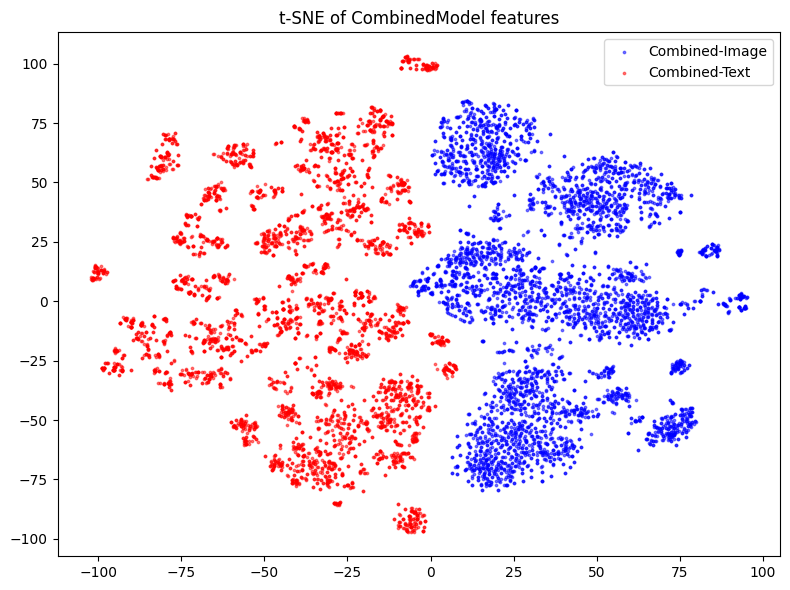

Generated CombinedModel features for 5000 images and 5000 texts.


In [8]:
# 使用已存在的 combined_model，统一 dtype 并进行子集编码 + t-SNE 可视化
import torch
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# 确保模型在评估模式
combined_model.eval()

# 统一 dtype 为 float32，避免 Half/Float 不匹配
combined_model.clip_model = combined_model.clip_model.to(dtype=torch.float32)
combined_model.visual_projector = combined_model.visual_projector.to(dtype=torch.float32)
combined_model.text_projector = combined_model.text_projector.to(dtype=torch.float32)

# 批量编码
cmb_img_features_list = []
cmb_txt_features_list = []
batch_size = 64
n = len(images)
for i in range(0, n, batch_size):
    end = min(i + batch_size, n)
    batch_imgs = torch.cat(images[i:end])
    batch_text = torch.cat([clip.tokenize(c, truncate=True) for c in captions[i:end]])
    batch_imgs = batch_imgs.to(device)
    batch_text = batch_text.to(device)
    with torch.no_grad():
        img_feats, txt_feats = combined_model(batch_imgs, batch_text)
        # 归一化
        img_feats = img_feats / img_feats.norm(dim=-1, keepdim=True)
        txt_feats = txt_feats / txt_feats.norm(dim=-1, keepdim=True)
    cmb_img_features_list.append(img_feats.cpu())
    cmb_txt_features_list.append(txt_feats.cpu())

cmb_img_features = torch.cat(cmb_img_features_list).numpy()
cmb_txt_features = torch.cat(cmb_txt_features_list).numpy()

# t-SNE 可视化
combined_feats = np.concatenate([cmb_img_features, cmb_txt_features], axis=0)
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, n_iter=1000, verbose=1)
tsne_results = tsne.fit_transform(combined_feats)

image_tsne = tsne_results[:cmb_img_features.shape[0]]
text_tsne = tsne_results[cmb_img_features.shape[0]:]

plt.figure(figsize=(8, 6))
plt.scatter(image_tsne[:, 0], image_tsne[:, 1], s=3, c='blue', alpha=0.5, label='Combined-Image')
plt.scatter(text_tsne[:, 0], text_tsne[:, 1], s=3, c='red', alpha=0.5, label='Combined-Text')
plt.title('t-SNE of CombinedModel features')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Generated CombinedModel features for {cmb_img_features.shape[0]} images and {cmb_txt_features.shape[0]} texts.")

In [9]:
# 计算 CLIP 与 CombinedModel 的图文检索指标 (Recall@K & Median Rank)
import numpy as np


def compute_retrieval_metrics(img_feats, txt_feats, topks=(1, 5, 10)):
    # 确保 numpy 数组并 L2 归一化
    img = np.asarray(img_feats, dtype=np.float32)
    txt = np.asarray(txt_feats, dtype=np.float32)
    img = img / np.linalg.norm(img, axis=1, keepdims=True)
    txt = txt / np.linalg.norm(txt, axis=1, keepdims=True)

    # 余弦相似度矩阵 (N x N)
    sim = img @ txt.T

    def rank_matches(sim_matrix):
        n = sim_matrix.shape[0]
        ranks = np.empty(n, dtype=np.int32)
        for i in range(n):
            # 排序降序，找到匹配对 (同索引) 的排名（1-based）
            order = np.argsort(-sim_matrix[i])
            ranks[i] = np.where(order == i)[0][0] + 1
        return ranks

    i2t_ranks = rank_matches(sim)
    t2i_ranks = rank_matches(sim.T)

    metrics = {}
    for k in topks:
        metrics[f"i2t_r@{k}"] = float(np.mean(i2t_ranks <= k) * 100)
        metrics[f"t2i_r@{k}"] = float(np.mean(t2i_ranks <= k) * 100)
    metrics["i2t_med_rank"] = float(np.median(i2t_ranks))
    metrics["t2i_med_rank"] = float(np.median(t2i_ranks))
    return metrics


def print_metrics(name, metrics):
    print(f"--- {name} ---")
    print("Image→Text: " + ", ".join([f"R@{k}: {metrics[f'i2t_r@{k}']:.2f}%" for k in (1, 5, 10)]))
    print("Text→Image: " + ", ".join([f"R@{k}: {metrics[f't2i_r@{k}']:.2f}%" for k in (1, 5, 10)]))
    print(f"Median Rank (I→T / T→I): {metrics['i2t_med_rank']:.1f} / {metrics['t2i_med_rank']:.1f}")


# 计算 CLIP (medtrinity_* 来自前一单元) 指标
clip_metrics = compute_retrieval_metrics(medtrinity_img_features, medtrinity_txt_features)
print_metrics("CLIP RN50", clip_metrics)

# 计算 CombinedModel 指标（cmb_* 来自前一单元）
combined_metrics = compute_retrieval_metrics(cmb_img_features, cmb_txt_features)
print_metrics("CombinedModel", combined_metrics)


--- CLIP RN50 ---
Image→Text: R@1: 0.32%, R@5: 1.10%, R@10: 1.56%
Text→Image: R@1: 0.22%, R@5: 0.60%, R@10: 1.04%
Median Rank (I→T / T→I): 728.5 / 781.0
--- CombinedModel ---
Image→Text: R@1: 0.30%, R@5: 0.72%, R@10: 1.24%
Text→Image: R@1: 0.20%, R@5: 0.68%, R@10: 1.02%
Median Rank (I→T / T→I): 1153.5 / 1262.0


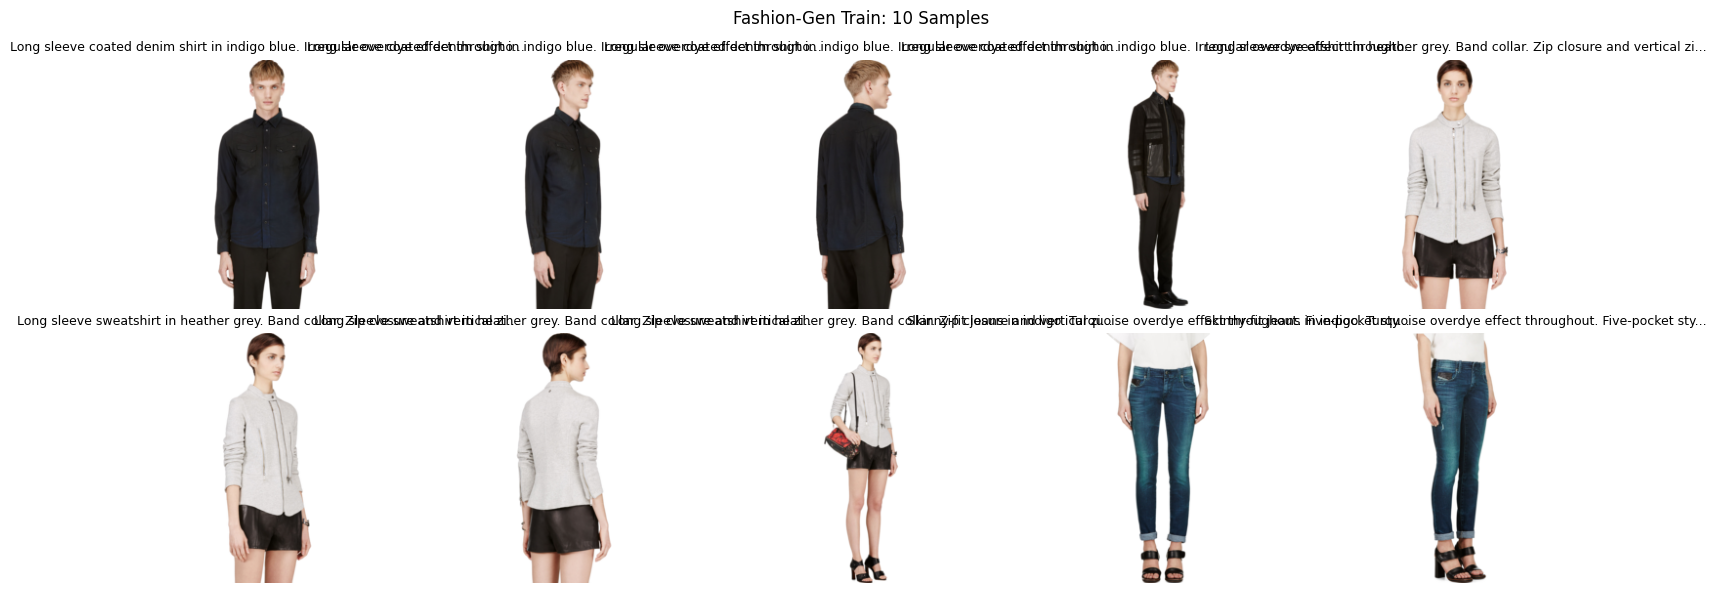

Done: visualized 10 samples from fashiongen_256_256_train.h5


In [11]:
# 读取 Fashion-Gen 训练集，抽取 10 个样本并可视化图像与描述
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

if 'dir_fashion_gen' not in globals():
    dir_fashion_gen = "/mnt/data/zs/data/fashion-gen/"

train_path = os.path.join(dir_fashion_gen, "fashiongen_256_256_train.h5")
assert os.path.exists(train_path), f"missing file: {train_path}"

with h5py.File(train_path, "r") as f:
    # 常见键：input_image, input_description；如有差异请打印 f.keys()
    imgs = f["input_image"]
    descs = f["input_description"]
    n = min(10, imgs.shape[0])

    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()

    for ax_idx in range(10):
        axes[ax_idx].axis("off")

    for i in range(n):
        img = imgs[i]
        # 处理通道顺序
        if img.ndim == 3:
            if img.shape[0] in (1, 3):  # CHW -> HWC
                img = np.transpose(img, (1, 2, 0))
            # 如果是 HW 或 HWC，直接使用
        img = np.array(img)
        # 如果是 1 通道，复制到 3 通道以便显示
        if img.ndim == 2:
            img = np.stack([img] * 3, axis=-1)
        if img.shape[-1] == 1:
            img = np.repeat(img, 3, axis=-1)
        # 将值归一到 0-1 范围
        img_min, img_max = img.min(), img.max()
        if img_max > img_min:
            img = (img - img_min) / (img_max - img_min)
        img = np.clip(img, 0, 1)

        raw_desc = descs[i]
        if isinstance(raw_desc, (bytes, bytearray)):
            desc = raw_desc.decode("utf-8", errors="ignore")
        else:
            # 可能是 ndarray of bytes
            if hasattr(raw_desc, "tolist"):
                raw_desc = raw_desc.tolist()
            if isinstance(raw_desc, (list, tuple)):
                raw_desc = b"".join(raw_desc)
            desc = str(raw_desc) if not isinstance(raw_desc, (bytes, bytearray)) else raw_desc.decode("utf-8", errors="ignore")
        desc = desc.strip()
        if len(desc) > 80:
            desc = desc[:80] + "..."

        ax = axes[i]
        ax.imshow(img)
        ax.set_title(desc, fontsize=9)
        ax.axis("off")

    plt.suptitle("Fashion-Gen Train: 10 Samples", fontsize=12)
    plt.tight_layout()
    plt.show()

print("Done: visualized 10 samples from fashiongen_256_256_train.h5")


Prepared 1000 samples from Fashion-Gen train
CLIP feats: (1000, 1024), (1000, 1024); Combined feats: (1000, 1024), (1000, 1024)


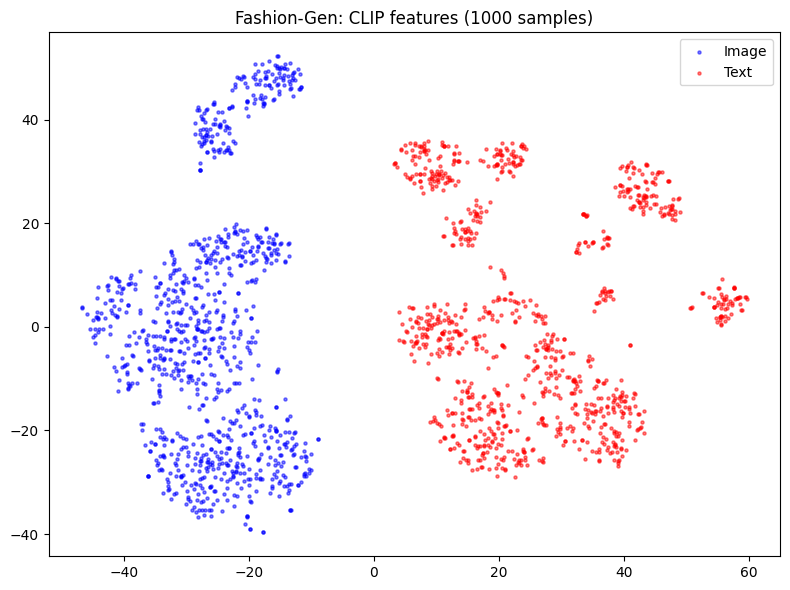

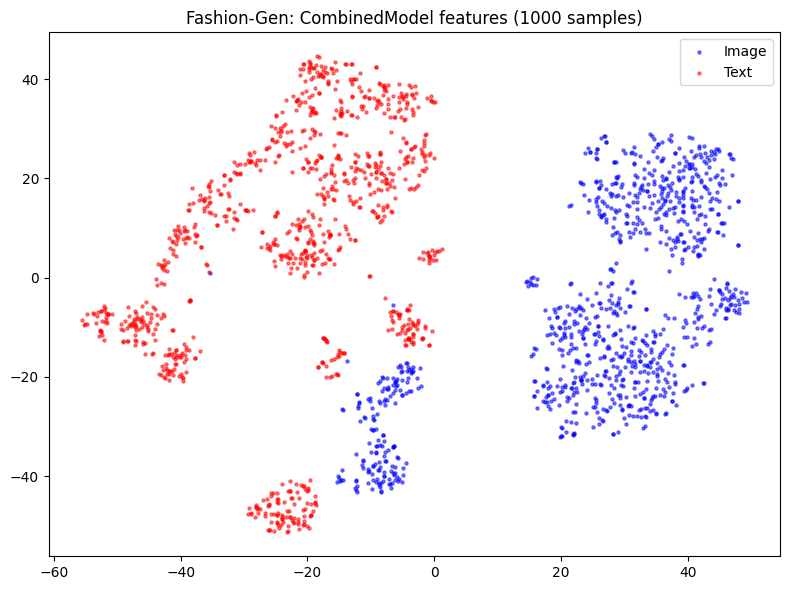

--- CLIP RN50 ---
Image→Text: R@1: 18.10%, R@5: 37.80%, R@10: 49.40%
Text→Image: R@1: 19.60%, R@5: 41.50%, R@10: 51.60%
Median Rank (I→T / T→I): 11.0 / 10.0
--- CombinedModel ---
Image→Text: R@1: 7.00%, R@5: 16.40%, R@10: 24.00%
Text→Image: R@1: 6.60%, R@5: 18.80%, R@10: 25.40%
Median Rank (I→T / T→I): 65.0 / 50.5


In [13]:
# Fashion-Gen: 抽取 1000 样本，分别用 CLIP 与 Combined 模型做 t-SNE 与检索指标
import os
import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.manifold import TSNE

# 路径与设备
if 'dir_fashion_gen' not in globals():
    dir_fashion_gen = "/mnt/data/zs/data/fashion-gen/"
train_path = os.path.join(dir_fashion_gen, "fashiongen_256_256_train.h5")
assert os.path.exists(train_path), f"missing file: {train_path}"

device = "cuda" if torch.cuda.is_available() else "cpu"
clip_model = clip_model.to(device)
# 确保 combined_model 浮点精度一致
combined_model.clip_model = combined_model.clip_model.to(dtype=torch.float32, device=device)
combined_model.visual_projector = combined_model.visual_projector.to(dtype=torch.float32, device=device)
combined_model.text_projector = combined_model.text_projector.to(dtype=torch.float32, device=device)
combined_model.eval()

num_samples = 1000
images = []
captions = []

with h5py.File(train_path, "r") as f:
    imgs = f["input_image"]
    descs = f["input_description"]
    total = imgs.shape[0]
    choose = min(num_samples, total)
    idx = np.random.choice(total, size=choose, replace=False)

    for j in idx:
        arr = np.array(imgs[j])
        if arr.ndim == 3 and arr.shape[0] in (1, 3):  # CHW -> HWC
            arr = np.transpose(arr, (1, 2, 0))
        if arr.ndim == 2:
            arr = np.stack([arr] * 3, axis=-1)
        if arr.shape[-1] == 1:
            arr = np.repeat(arr, 3, axis=-1)
        arr_min, arr_max = arr.min(), arr.max()
        if arr_max > arr_min:
            arr = (arr - arr_min) / (arr_max - arr_min)
        arr = np.clip(arr * 255, 0, 255).astype(np.uint8)
        pil_img = Image.fromarray(arr).convert("RGB")
        images.append(img_preprocess(pil_img).unsqueeze(0))

        raw_desc = descs[j]
        if isinstance(raw_desc, (bytes, bytearray)):
            desc = raw_desc.decode("utf-8", errors="ignore")
        else:
            if hasattr(raw_desc, "tolist"):
                raw_desc = raw_desc.tolist()
            if isinstance(raw_desc, (list, tuple)):
                raw_desc = b"".join(raw_desc)
            desc = raw_desc.decode("utf-8", errors="ignore") if isinstance(raw_desc, (bytes, bytearray)) else str(raw_desc)
        captions.append(desc.strip())

print(f"Prepared {len(images)} samples from Fashion-Gen train")


def encode_clip(image_tensors, text_list, model, device, batch=32):
    img_feats, txt_feats = [], []
    with torch.no_grad():
        for i in range(0, len(image_tensors), batch):
            b_imgs = torch.cat(image_tensors[i:i+batch]).to(device)
            b_txt = clip.tokenize(text_list[i:i+batch], truncate=True).to(device)
            im = model.encode_image(b_imgs).float()
            tx = model.encode_text(b_txt).float()
            im = im / im.norm(dim=-1, keepdim=True)
            tx = tx / tx.norm(dim=-1, keepdim=True)
            img_feats.append(im.cpu())
            txt_feats.append(tx.cpu())
    return torch.cat(img_feats).numpy(), torch.cat(txt_feats).numpy()


def encode_combined(image_tensors, text_list, model, device, batch=32):
    img_feats, txt_feats = [], []
    with torch.no_grad():
        for i in range(0, len(image_tensors), batch):
            b_imgs = torch.cat(image_tensors[i:i+batch]).to(device)
            b_txt = clip.tokenize(text_list[i:i+batch], truncate=True).to(device)
            im, tx = model(b_imgs, b_txt)
            im = im / im.norm(dim=-1, keepdim=True)
            tx = tx / tx.norm(dim=-1, keepdim=True)
            img_feats.append(im.cpu())
            txt_feats.append(tx.cpu())
    return torch.cat(img_feats).numpy(), torch.cat(txt_feats).numpy()


clip_img_f, clip_txt_f = encode_clip(images, captions, clip_model, device)
cmb_img_f, cmb_txt_f = encode_combined(images, captions, combined_model, device)

print(f"CLIP feats: {clip_img_f.shape}, {clip_txt_f.shape}; Combined feats: {cmb_img_f.shape}, {cmb_txt_f.shape}")


def plot_tsne(img_feats, txt_feats, title):
    combined = np.concatenate([img_feats, txt_feats], axis=0)
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    res = tsne.fit_transform(combined)
    img_tsne = res[:img_feats.shape[0]]
    txt_tsne = res[img_feats.shape[0]:]
    plt.figure(figsize=(8, 6))
    plt.scatter(img_tsne[:, 0], img_tsne[:, 1], s=5, c='blue', alpha=0.5, label='Image')
    plt.scatter(txt_tsne[:, 0], txt_tsne[:, 1], s=5, c='red', alpha=0.5, label='Text')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_tsne(clip_img_f, clip_txt_f, "Fashion-Gen: CLIP features (1000 samples)")
plot_tsne(cmb_img_f, cmb_txt_f, "Fashion-Gen: CombinedModel features (1000 samples)")


def compute_retrieval_metrics(img_feats, txt_feats, topks=(1, 5, 10)):
    img = np.asarray(img_feats, dtype=np.float32)
    txt = np.asarray(txt_feats, dtype=np.float32)
    img = img / np.linalg.norm(img, axis=1, keepdims=True)
    txt = txt / np.linalg.norm(txt, axis=1, keepdims=True)
    sim = img @ txt.T

    def rank_matches(sim_matrix):
        n = sim_matrix.shape[0]
        ranks = np.empty(n, dtype=np.int32)
        for i in range(n):
            order = np.argsort(-sim_matrix[i])
            ranks[i] = np.where(order == i)[0][0] + 1
        return ranks

    i2t_ranks = rank_matches(sim)
    t2i_ranks = rank_matches(sim.T)

    metrics = {}
    for k in topks:
        metrics[f"i2t_r@{k}"] = float(np.mean(i2t_ranks <= k) * 100)
        metrics[f"t2i_r@{k}"] = float(np.mean(t2i_ranks <= k) * 100)
    metrics["i2t_med_rank"] = float(np.median(i2t_ranks))
    metrics["t2i_med_rank"] = float(np.median(t2i_ranks))
    return metrics


def print_metrics(name, m):
    print(f"--- {name} ---")
    print("Image→Text: " + ", ".join([f"R@{k}: {m[f'i2t_r@{k}']:.2f}%" for k in (1, 5, 10)]))
    print("Text→Image: " + ", ".join([f"R@{k}: {m[f't2i_r@{k}']:.2f}%" for k in (1, 5, 10)]))
    print(f"Median Rank (I→T / T→I): {m['i2t_med_rank']:.1f} / {m['t2i_med_rank']:.1f}")

clip_metrics = compute_retrieval_metrics(clip_img_f, clip_txt_f)
combined_metrics = compute_retrieval_metrics(cmb_img_f, cmb_txt_f)
print_metrics("CLIP RN50", clip_metrics)
print_metrics("CombinedModel", combined_metrics)


In [14]:
# 查看 Fashion-Gen 训练集的所有属性名称（HDF5 keys/columns）
import os
import h5py

if 'dir_fashion_gen' not in globals():
    dir_fashion_gen = "/mnt/data/zs/data/fashion-gen/"
train_path = os.path.join(dir_fashion_gen, "fashiongen_256_256_train.h5")
assert os.path.exists(train_path), f"missing file: {train_path}"

with h5py.File(train_path, "r") as f:
    print("Keys in H5 file:", list(f.keys()))
    # 若有 attrs，可一并打印
    if len(f.attrs.keys()) > 0:
        print("File-level attrs:", dict(f.attrs))
    # 展示每个 key 的形状和 dtype
    for k in f.keys():
        dset = f[k]
        print(f"{k}: shape={dset.shape}, dtype={dset.dtype}")


Keys in H5 file: ['index', 'index_2', 'input_brand', 'input_category', 'input_composition', 'input_concat_description', 'input_department', 'input_description', 'input_gender', 'input_image', 'input_msrpUSD', 'input_name', 'input_pose', 'input_productID', 'input_season', 'input_subcategory']
File-level attrs: {'input_names': array([b'index', b'input_brand', b'input_category', b'input_composition',
       b'input_concat_description', b'input_department',
       b'input_description', b'input_gender', b'input_image',
       b'input_msrpUSD', b'input_name', b'input_pose', b'input_productID',
       b'input_season', b'input_subcategory'], dtype='|S24'), 'output_names': array([], dtype=float64), 'split': array([(b'all', b'index', 0, 260490, <HDF5 object reference (null)>,  True, b'.'),
       (b'all', b'input_brand', 0, 260490, <HDF5 object reference (null)>,  True, b'.'),
       (b'all', b'input_category', 0, 260490, <HDF5 object reference (null)>,  True, b'.'),
       (b'all', b'input_comp

## Fashion-Gen 预处理（CLIP RN50 + HF datasets 保存）
- 保留 `index`、`input_image`、`input_description`、`input_category`
- 统一类别映射为 `class_id`，并用 CLIP RN50 生成 `image_emb` 与 `discri_emb`
- 将 train/test 以 HuggingFace datasets `save_to_disk` 形式写入 `preprocessed_fashion/`

In [ ]:
import os, json, h5py, numpy as np, torch
import clip
from PIL import Image
from datasets import Dataset, Features, Value, Image as HFImage, Sequence, ClassLabel

# 路径与模型
device = "cuda" if torch.cuda.is_available() else "cpu"
clip_model, img_preprocess = clip.load("RN50", device=device)
clip_model.eval()
clip_dim = clip_model.text_projection.shape[1]

if 'dir_fashion_gen' not in globals():
    dir_fashion_gen = "/mnt/data/zs/data/fashion-gen/"
train_path = os.path.join(dir_fashion_gen, "fashiongen_256_256_train.h5")

def pick_split(options):
    for fname in options:
        cand = os.path.join(dir_fashion_gen, fname)
        if os.path.exists(cand):
            return cand
    raise FileNotFoundError("No validation/test split found in dir_fashion_gen")

test_path = pick_split([
    "fashiongen_256_256_validation.h5",
    "fashiongen_256_256_valid.h5",
    "fashiongen_256_256_test.h5",
])

# 收集类别映射
def collect_categories(paths, key="input_category", step=50000):
    cats = set()
    for path in paths:
        with h5py.File(path, "r") as f:
            data = f[key]
            total = len(data)
            for start in range(0, total, step):
                end = min(start + step, total)
                batch = data[start:end]
                for v in batch:
                    if isinstance(v, bytes):
                        cats.add(v.decode("utf-8"))
                    else:
                        cats.add(str(v))
    return sorted(cats)

class_names = collect_categories([train_path, test_path])
label2id = {c: i for i, c in enumerate(class_names)}

base_features = Features({
    "index": Value("int64"),
    "input_image": HFImage(),
    "input_description": Value("string"),
    "input_category": Value("string"),
})

def gen_examples(path):
    def _gen():
        with h5py.File(path, "r") as f:
            imgs = f["input_image"]
            descs = f["input_description"]
            cats = f["input_category"]
            idxs = f["index"] if "index" in f else None
            total = len(imgs)
            for i in range(total):
                desc = descs[i]
                cat = cats[i]
                yield {
                    "index": int(idxs[i]) if idxs is not None else i,
                    "input_image": imgs[i],
                    "input_description": desc.decode("utf-8") if isinstance(desc, bytes) else str(desc),
                    "input_category": cat.decode("utf-8") if isinstance(cat, bytes) else str(cat),
                }
    return _gen

train_ds = Dataset.from_generator(gen_examples(train_path), features=base_features)
test_ds = Dataset.from_generator(gen_examples(test_path), features=base_features)

def add_embeds(batch):
    pil_imgs = [img if isinstance(img, Image.Image) else Image.fromarray(np.array(img)) for img in batch["input_image"]]
    pixel_values = torch.stack([img_preprocess(im) for im in pil_imgs]).to(device)
    text_tokens = clip.tokenize(batch["input_description"], truncate=True).to(device)
    with torch.no_grad():
        img_feat = clip_model.encode_image(pixel_values)
        txt_feat = clip_model.encode_text(text_tokens)
        img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)
        txt_feat = txt_feat / txt_feat.norm(dim=-1, keepdim=True)
    img_feat = img_feat.cpu().numpy().astype("float32")
    txt_feat = txt_feat.cpu().numpy().astype("float32")
    class_ids = [label2id[c] for c in batch["input_category"]]
    return {"image_emb": img_feat, "discri_emb": txt_feat, "class_id": class_ids}

train_ds = train_ds.map(add_embeds, batched=True, batch_size=32)
test_ds = test_ds.map(add_embeds, batched=True, batch_size=32)

final_features = Features({
    "index": Value("int64"),
    "input_image": HFImage(),
    "input_description": Value("string"),
    "input_category": Value("string"),
    "class_id": ClassLabel(names=class_names),
    "image_emb": Sequence(Value("float32"), length=clip_dim),
    "discri_emb": Sequence(Value("float32"), length=clip_dim),
})
train_ds = train_ds.cast(final_features)
test_ds = test_ds.cast(final_features)

output_dir = os.path.join(os.getcwd(), "preprocessed_fashion")
os.makedirs(output_dir, exist_ok=True)
train_out = os.path.join(output_dir, "train")
test_out = os.path.join(output_dir, "test")
train_ds.save_to_disk(train_out)
test_ds.save_to_disk(test_out)
with open(os.path.join(output_dir, "label2id.json"), "w", encoding="utf-8") as f:
    json.dump(label2id, f, ensure_ascii=False, indent=2)

print(f"Saved train to {train_out} ({len(train_ds)} samples)")
print(f"Saved test to {test_out} ({len(test_ds)} samples)")
print(f"Classes: {len(class_names)}; mapping stored at {os.path.join(output_dir, 'label2id.json')}")

Generating train split: 0 examples [00:00, ? examples/s]/tmp/ipykernel_2510458/3376791262.py:68: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "index": int(idxs[i]) if idxs is not None else i,
Generating train split: 260490 examples [45:44, 94.90 examples/s] 
Generating train split: 32528 examples [05:28, 99.15 examples/s] 
Saving the dataset (13/20 shards):  70%|██████▉   | 181322/260490 [13:13<04:45, 277.08 examples/s]

## UMPC-FOOD-101 数据集结构与可视化
- 根目录：`/mnt/data/zs/data/UMPC-FOOD-101`，子目录通常包含 `images/`（图像）与 `texts/`（元数据）。
- 读取规则：优先解析 `texts/` 下的 json/jsonl/csv/tsv/txt 获取 `image`、`description`/`text` 与 `label`/`category` 字段；若未找到元数据，则从 `images/` 目录结构中推断类别（子文件夹名）并使用占位描述。
- 输出：随机抽取 10 条样本，展示图像、截断描述与类别标签，便于快速核查数据组织是否正确。

Total entries detected: 90704; showing 10 samples


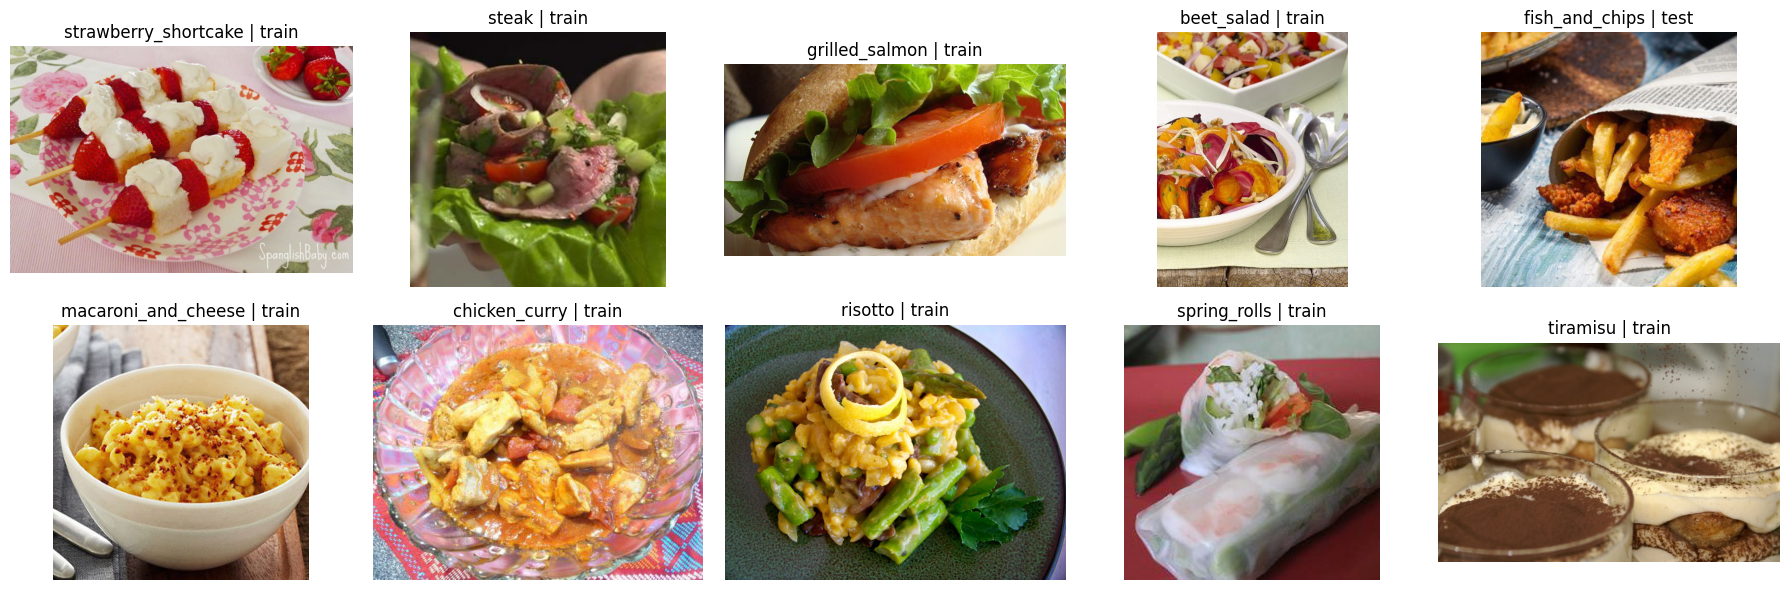

README snippet:
 # UMPC-FOOD-101 数据集说明

## 数据集概览
- 内容：101 个食物类别的图像分类数据集，已按训练集与测试集分好目录。
- 组成：图像位于 images/ 下的 train/ 与 test/ 目录；与图像配套的文本信息位于 texts/ 目录。
- 目标：可用于多模态（图像 + 文本）或纯图像的分类、检索、对比学习等任务。

## 目录结构
```
UMPC-FOOD-101/
├── images/
│   ├── train/
│   │   ├── apple_pie/
│   │   ├── ... (其余 100 个类别)
│   └── test/
│       ├── apple_pie/
│       ├── ... (其余 100 个类别)
└── texts/
	├── train_titles.csv
	└── test_titles.csv


In [3]:
import os, random, textwrap
from pathlib import Path
from typing import List, Dict, Any, Optional
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np

base_dir = Path("/mnt/data/zs/data/UMPC-FOOD-101")
images_dir = base_dir / "images"
texts_dir = base_dir / "texts"
train_csv = texts_dir / "train_titles.csv"
test_csv = texts_dir / "test_titles.csv"

def read_readme(path: Path) -> str:
    if path.exists():
        try:
            return path.read_text(encoding="utf-8")
        except Exception:
            return path.read_text(errors="ignore")
    return ""

def load_csv(path: Path) -> Optional[pd.DataFrame]:
    if not path.exists() or path.stat().st_size == 0:
        return None
    try:
        df = pd.read_csv(path)
        # 约定：第一列=文件名，第二列=描述，第三列=类别
        if df.shape[1] >= 3:
            df.columns = ["filename", "description", "label"] + list(df.columns[3:])
        return df
    except Exception as e:
        print(f"Skip {path} due to error: {e}")
        return None

def build_entries_for_split(split: str, meta_df: Optional[pd.DataFrame]) -> List[Dict[str, Any]]:
    split_dir = images_dir / split
    if not split_dir.exists():
        return []
    label_dirs = [p for p in split_dir.iterdir() if p.is_dir()]
    meta_by_fname: Dict[str, Dict[str, str]] = {}
    if meta_df is not None and not meta_df.empty:
        for _, row in meta_df.iterrows():
            fname = str(row.get("filename", "")).strip()
            if not fname:
                continue
            meta_by_fname[fname] = {
                "description": str(row.get("description", "")).strip(),
                "label": str(row.get("label", "")).strip(),
            }
    entries: List[Dict[str, Any]] = []
    for cls_dir in label_dirs:
        cls = cls_dir.name
        for img_file in cls_dir.glob("*.jpg"):
            meta = meta_by_fname.get(img_file.name, {})
            label = meta.get("label") or cls
            desc = meta.get("description", "")
            rel_path = img_file.relative_to(images_dir)
            entries.append({
                "split": split,
                "image": rel_path,
                "label": label,
                "description": desc if desc else label,
            })
    return entries

def load_entries() -> List[Dict[str, Any]]:
    train_meta = load_csv(train_csv)
    test_meta = load_csv(test_csv)
    entries = build_entries_for_split("train", train_meta) + build_entries_for_split("test", test_meta)
    if not entries:
        print("No metadata or images found; please check dataset path.")
    unique = {}
    for e in entries:
        key = str(e.get("image", ""))
        if key and key not in unique:
            unique[key] = e
    return list(unique.values())

def sample_entries(entries: List[Dict[str, Any]], k: int = 10) -> List[Dict[str, Any]]:
    if len(entries) <= k:
        return entries
    return random.sample(entries, k)

def load_image_safe(rel_path: Path) -> Image.Image:
    img_path = images_dir / rel_path
    if not img_path.exists():
        return Image.new("RGB", (256, 256), color=(200, 200, 200))
    try:
        return Image.open(img_path).convert("RGB")
    except Exception:
        return Image.new("RGB", (256, 256), color=(200, 0, 0))

readme_txt = read_readme(base_dir / "README.md")
entries = load_entries()
samples = sample_entries(entries, k=10)
print(f"Total entries detected: {len(entries)}; showing {len(samples)} samples")

cols = 5
rows = int(np.ceil(len(samples) / cols)) or 1
fig, axes = plt.subplots(rows, cols, figsize=(18, 6))
axes = np.array(axes).reshape(rows, cols)
for ax, sample in zip(axes.flatten(), samples):
    img = load_image_safe(sample.get("image", ""))
    ax.imshow(img)
    label = sample.get("label", "").strip()
    desc = sample.get("description", "").strip()
    desc_short = textwrap.shorten(desc, width=80, placeholder="...") if desc else "(no description)"
    split = sample.get("split", "")
    ax.set_title(f"{label} | {split}")
    ax.set_xlabel(desc_short)
    ax.axis("off")
for ax in axes.flatten()[len(samples):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

if readme_txt:
    print("README snippet:\n", "\n".join(readme_txt.splitlines()[:20]))
else:
    print("README not found or empty.")

## UMPC-FOOD-101 t-SNE（CLIP & combined_model）
- 读取 `images/train`+`images/test` 与 CSV（第一列文件名、第二列描述、第三列类别），抽样平衡子集。
- 使用 CLIP 生成图像与文本嵌入，若存在 `combined_model`（需提供 `encode_image`/`encode_text`，输入为已归一化张量/文本 token）则一并可视化。
- 输出两张 t-SNE 图：CLIP，以及可选 combined_model（若未定义则跳过）。

Selected 300 samples across 38 classes


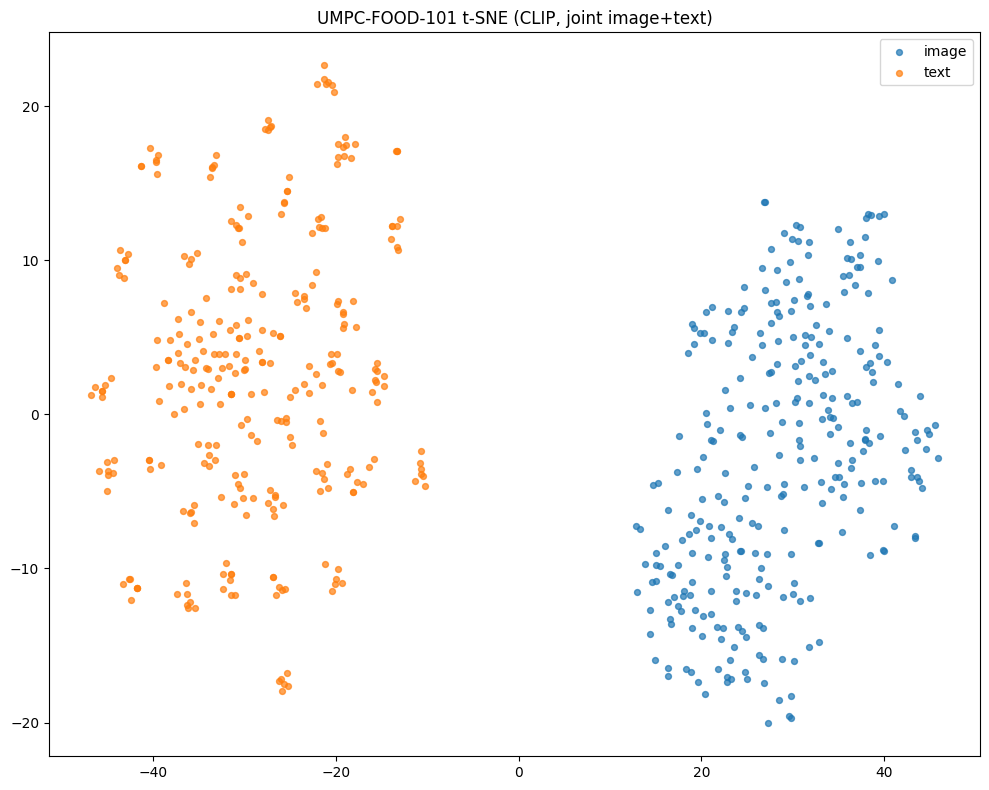

combined_model 未提供，已跳过 combined_model t-SNE


In [6]:
import torch
from sklearn.manifold import TSNE
from collections import defaultdict
import clip

base_dir = Path("/mnt/data/zs/data/UMPC-FOOD-101")
images_dir = base_dir / "images"
texts_dir = base_dir / "texts"
train_csv = texts_dir / "train_titles.csv"
test_csv = texts_dir / "test_titles.csv"
if 'entries' not in globals():
    entries = load_entries()
samples = sample_entries(entries, k=len(entries))

max_per_class = 8
total_limit = 300
by_cls = defaultdict(list)
for e in entries:
    by_cls[e['label']].append(e)
selected = []
for cls, items in by_cls.items():
    random.shuffle(items)
    selected.extend(items[:max_per_class])
    if len(selected) >= total_limit:
        break
selected = selected[:total_limit]
print(f"Selected {len(selected)} samples across {len(set(e['label'] for e in selected))} classes")

device = "cuda" if torch.cuda.is_available() else "cpu"
clip_model, clip_preprocess = clip.load("RN50", device=device)
clip_model.eval()

def preprocess_image(rel_path: Path):
    img = load_image_safe(rel_path)
    return clip_preprocess(img)

def get_clip_embeds(batch):
    imgs = torch.stack([preprocess_image(e['image']) for e in batch]).to(device)
    texts = clip.tokenize([e['description'] for e in batch], truncate=True).to(device)
    with torch.no_grad():
        img_feat = clip_model.encode_image(imgs)
        txt_feat = clip_model.encode_text(texts)
        img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)
        txt_feat = txt_feat / txt_feat.norm(dim=-1, keepdim=True)
    return img_feat.cpu(), txt_feat.cpu()

def run_tsne(feats):
    feats_np = feats.numpy()
    tsne = TSNE(n_components=2, init='pca', learning_rate='auto', perplexity=min(30, max(2, len(feats_np)-1)), random_state=42)
    return tsne.fit_transform(feats_np)

def plot_joint_modal_tsne(emb2d, n_img, labels, title):
    img_pts = emb2d[:n_img]
    txt_pts = emb2d[n_img:]
    plt.figure(figsize=(10, 8))
    plt.scatter(img_pts[:, 0], img_pts[:, 1], s=18, alpha=0.7, c='tab:blue', label='image')
    plt.scatter(txt_pts[:, 0], txt_pts[:, 1], s=18, alpha=0.7, c='tab:orange', label='text')
    plt.legend(loc='best')
    plt.title(title)
    plt.tight_layout()
    plt.show()

# CLIP：图像与文本表征合并做一次 t-SNE，保证降维一致
clip_img_feat_list = []
clip_txt_feat_list = []
labels = []
for e in selected:
    img_f, txt_f = get_clip_embeds([e])
    clip_img_feat_list.append(img_f)
    clip_txt_feat_list.append(txt_f)
    labels.append(e['label'])
clip_img_feat = torch.cat(clip_img_feat_list, dim=0)
clip_txt_feat = torch.cat(clip_txt_feat_list, dim=0)
clip_feat_all = torch.cat([clip_img_feat, clip_txt_feat], dim=0)
emb2d_clip = run_tsne(clip_feat_all)
plot_joint_modal_tsne(emb2d_clip, n_img=len(clip_img_feat), labels=labels, title="UMPC-FOOD-101 t-SNE (CLIP, joint image+text)")

# combined_model（可选），同样合并后统一 t-SNE
if 'combined_model' in globals() and hasattr(combined_model, 'encode_image') and hasattr(combined_model, 'encode_text'):
    ci_list, ct_list = [], []
    for e in selected:
        img_tensor = preprocess_image(e['image']).unsqueeze(0).to(device)
        text_tokens = clip.tokenize([e['description']], truncate=True).to(device)
        with torch.no_grad():
            ci = combined_model.encode_image(img_tensor)
            ct = combined_model.encode_text(text_tokens)
            ci = ci / ci.norm(dim=-1, keepdim=True)
            ct = ct / ct.norm(dim=-1, keepdim=True)
        ci_list.append(ci.cpu())
        ct_list.append(ct.cpu())
    ci_feat = torch.cat(ci_list, dim=0)
    ct_feat = torch.cat(ct_list, dim=0)
    comb_feat_all = torch.cat([ci_feat, ct_feat], dim=0)
    emb2d_comb = run_tsne(comb_feat_all)
    plot_joint_modal_tsne(emb2d_comb, n_img=len(ci_feat), labels=labels, title="UMPC-FOOD-101 t-SNE (combined_model, joint image+text)")
else:
    print("combined_model 未提供，已跳过 combined_model t-SNE")

## 预处理后的 Fashion 数据集检查与可视化
- 读取 `preprocessed_fashion/train` 与 `preprocessed_fashion/test`
- 打印特征架构与样本计数
- 随机抽取 10 个样本（train）展示图像、描述、类别

/mnt/data/software/anaconda/envs/zs_vita/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading preprocessed fashion datasets...
Dataset({
    features: ['index', 'input_image', 'input_description', 'input_category', 'class_id', 'image_emb', 'discri_emb'],
    num_rows: 260490
})
Dataset({
    features: ['index', 'input_image', 'input_description', 'input_category', 'class_id', 'image_emb', 'discri_emb'],
    num_rows: 32528
})
Train features: {'index': Value(dtype='int64', id=None), 'input_image': Image(mode=None, decode=True, id=None), 'input_description': Value(dtype='string', id=None), 'input_category': Value(dtype='string', id=None), 'class_id': ClassLabel(names=["[b'BACKPACKS']", "[b'BAG ACCESSORIES']", "[b'BELTS & SUSPENDERS']", "[b'BLANKETS']", "[b'BOAT SHOES & MOCCASINS']", "[b'BOOTS']", "[b'BRIEFCASES']", "[b'CLUTCHES & POUCHES']", "[b'DRESSES']", "[b'DUFFLE & TOP HANDLE BAGS']", "[b'DUFFLE BAGS']", "[b'ESPADRILLES']", "[b'EYEWEAR']", "[b'FINE JEWELRY']", "[b'FLATS']", "[b'GLOVES']", "[b'HATS']", "[b'HEELS']", "[b'JACKETS & COATS']", "[b'JEANS']", "[b'JEWELRY']"

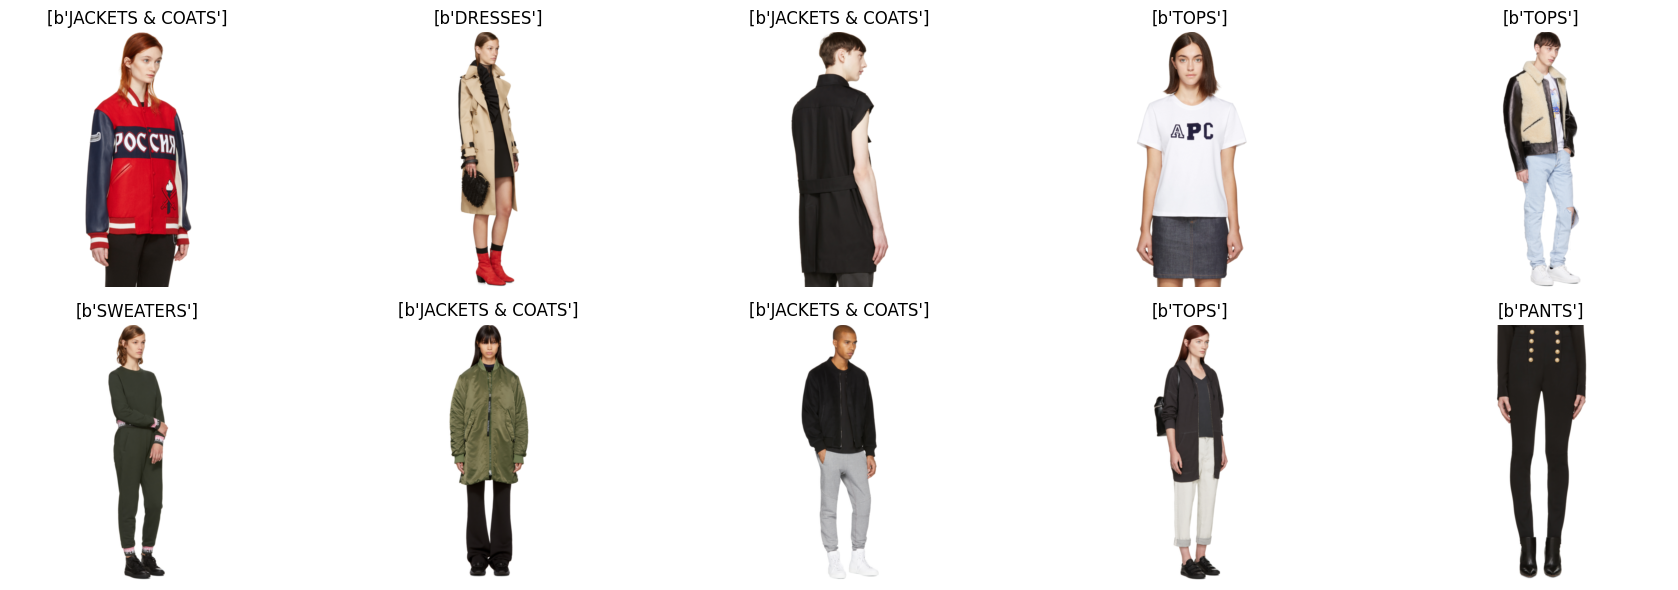

In [7]:
import random
from datasets import load_from_disk
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

FASHION_ROOT = "/home/bd/data/zs/FedMMDP/preprocessed_fashion"
train_path = f"{FASHION_ROOT}/train"
test_path = f"{FASHION_ROOT}/test"

print("Loading preprocessed fashion datasets...")
train_ds = load_from_disk(train_path)
test_ds = load_from_disk(test_path)
print(train_ds)
print(test_ds)

print("Train features:", train_ds.features)
print("Test features:", test_ds.features)
print(f"Train size: {len(train_ds)}, Test size: {len(test_ds)}")

def show_samples(ds, k=10):
    idxs = random.sample(range(len(ds)), k=min(k, len(ds)))
    samples = ds.select(idxs)
    cols = 5
    rows = int(np.ceil(len(samples) / cols)) or 1
    fig, axes = plt.subplots(rows, cols, figsize=(18, 6))
    axes = np.array(axes).reshape(rows, cols)
    for ax, ex in zip(axes.flatten(), samples):
        img = ex["input_image"]
        if not isinstance(img, Image.Image):
            img = Image.fromarray(np.array(img))
        ax.imshow(img)
        label = ex.get("input_category", "")
        desc = ex.get("input_description", "")
        desc_short = (desc[:60] + "...") if len(desc) > 60 else desc
        ax.set_title(label)
        ax.set_xlabel(desc_short)
        ax.axis("off")
    for ax in axes.flatten()[len(samples):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

print("Showing 10 random train samples...")
show_samples(train_ds, k=10)

In [1]:
import random
from datasets import load_from_disk

FASHION_ROOT = "/home/bd/data/zs/FedMMDP/preprocessed_fashion"
train_path = f"{FASHION_ROOT}/train"

# 若上一单元已加载 train_ds 则复用，否则重新加载
if 'train_ds' not in globals():
    train_ds = load_from_disk(train_path)
    print(f"Train dataset loaded: {len(train_ds)} samples")

k = 10
idxs = random.sample(range(len(train_ds)), k=min(k, len(train_ds)))
samples = train_ds.select(idxs)
for i, ex in enumerate(samples, 1):
    print(f"Sample {i}:")
    print("  id:", ex.get("index", ex.get("id", "")))
    print("  label:", ex.get("input_category", ""))
    print("  description:", ex.get("input_description", ""))
    print("---")

/mnt/data/software/anaconda/envs/zs_vita/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Train dataset loaded: 260490 samples
Sample 1:
  id: 317175
  label: [b'JACKETS & COATS']
  description: [b'Long sleeve Japanese denim jacket in blue. Fading and distressing throughout. Spread collar. Button closure at front. Flap pockets at bust. Welt pockets at waist. Single-button barrel cuffs. Adjustable cinch tabs at back hem. Antiqued copper-tone hardware. Contrast stitching in tan.']
---
Sample 2:
  id: 155844
  label: [b'PANTS']
  description: [b'Flared wool trousers in black. Four-pocket styling. Rolled cuffs. Zip-fly. Partially lined. Tonal stitching.']
---
Sample 3:
  id: 135106
  label: [b'TOPS']
  description: [b'Short sleeve t-shirt in white. Trapeze silhouette. Crewneck collar. Zip closure at shoulder. Patch pocket at chest. Pleated panel at back. Tonal stitching.']
---
Sample 4:
  id: 146090
  label: [b'TOPS']
  description: [b"Short sleeve cotton twill t-shirt in 'coal' black. Raw edges throughout. Crewneck collar. Accent seam at front. Tonal stitching."]
---
Sample 5:

In [1]:
import random
from datasets import load_from_disk

# 读取 Food 数据集
FOOD_ROOT = "/home/bd/data/zs/FedMMDP/preprocessed_food"
train_path = f"{FOOD_ROOT}/domain_datasets/domain_dataset_0/train"

print(f"Loading Food dataset from: {train_path}")
if 'food_train_ds' not in globals():
    food_train_ds = load_from_disk(train_path)
    print(f"✓ Food train dataset loaded: {len(food_train_ds)} samples")
else:
    print(f"✓ Food train dataset already loaded: {len(food_train_ds)} samples")

# 随机抽取10个样本
k = 10
idxs = random.sample(range(len(food_train_ds)), k=min(k, len(food_train_ds)))
samples = food_train_ds.select(idxs)

print(f"\n{'='*60}")
print(f"Randomly selected {len(samples)} samples from Food dataset:")
print(f"{'='*60}\n")

for i, ex in enumerate(samples, 1):
    print(f"Sample {i}:")
    print(f"  Index: {ex.get('index', ex.get('id', 'N/A'))}")
    
    # 处理类别（可能是 bytes）
    category = ex.get("input_category", ex.get("category", ""))
    if isinstance(category, bytes):
        category = category.decode('utf-8')
    print(f"  Category: {category}")
    
    # 处理描述（可能是 bytes）
    description = ex.get("input_description", ex.get("description", ""))
    if isinstance(description, bytes):
        description = description.decode('utf-8')
    print(f"  Description: {description[:100]}{'...' if len(description) > 100 else ''}")
    
    # 显示其他可能的字段
    if 'input_image' in ex:
        print(f"  Has Image: Yes")
    if 'text_embeds' in ex:
        print(f"  Text Embedding Shape: {ex['text_embeds'].shape if hasattr(ex['text_embeds'], 'shape') else 'N/A'}")
    if 'image_embeds' in ex:
        print(f"  Image Embedding Shape: {ex['image_embeds'].shape if hasattr(ex['image_embeds'], 'shape') else 'N/A'}")
    
    print("-" * 60)

# 显示数据集的完整字段信息
print(f"\n{'='*60}")
print("Dataset Schema:")
print(f"{'='*60}")
print(f"Available fields: {list(food_train_ds.features.keys())}")
print(f"\nDataset info:")
for key, feature in food_train_ds.features.items():
    print(f"  - {key}: {feature}")


/mnt/data/software/anaconda/envs/zs_vita/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/mnt/data/software/anaconda/envs/zs_vita/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading Food dataset from: /home/bd/data/zs/FedMMDP/preprocessed_food/domain_datasets/domain_dataset_0/train
✓ Food train dataset loaded: 14047 samples

Randomly selected 10 samples from Food dataset:

Sample 1:
  Index: samosa_524.jpg
  Category: 
  Description: 
------------------------------------------------------------
Sample 2:
  Index: apple_pie_912.jpg
  Category: 
  Description: 
------------------------------------------------------------
Sample 3:
  Index: hot_dog_817.jpg
  Category: 
  Description: 
------------------------------------------------------------
Sample 4:
  Index: pad_thai_254.jpg
  Category: 
  Description: 
------------------------------------------------------------
Sample 5:
  Index: sushi_149.jpg
  Category: 
  Description: 
------------------------------------------------------------
Sample 6:
  Index: grilled_salmon_51.jpg
  Category: 
  Description: 
------------------------------------------------------------
Sample 7:
  Index: pulled_pork_sandwich_28